<img src=../figures/Brown_logo.svg width=50%>

## Data-Driven Design & Analyses of Structures & Materials (3dasm)

## Lecture 7

### Miguel A. Bessa | <a href = "mailto: miguel_bessa@brown.edu">miguel_bessa@brown.edu</a>  | Associate Professor

**What:** A lecture of the "3dasm" course

**Where:** This notebook comes from this [repository](https://github.com/bessagroup/3dasm_course)

**Reference for entire course:** Murphy, Kevin P. *Probabilistic machine learning: an introduction*. MIT press, 2022. Available online [here](https://probml.github.io/pml-book/book1.html)

**How:** We try to follow Murphy's book closely, but the sequence of Chapters and Sections is different. The intention is to use notebooks as an introduction to the topic and Murphy's book as a resource.
* If working offline: Go through this notebook and read the book.
* If attending class in person: listen to me (!) but also go through the notebook in your laptop at the same time. Read the book.
* If attending lectures remotely: listen to me (!) via Zoom and (ideally) use two screens where you have the notebook open in 1 screen and you see the lectures on the other. Read the book.

**Optional reference (the "bible" by the "bishop"... pun intended 😆) :** Bishop, Christopher M. *Pattern recognition and machine learning*. Springer Verlag, 2006.

**References/resources to create this notebook:**
* [Car figure](https://korkortonline.se/en/theory/reaction-braking-stopping/)

Apologies in advance if I missed some reference used in this notebook. Please contact me if that is the case, and I will gladly include it here.

## **OPTION 1**. Run this notebook **locally in your computer**:
1. Confirm that you have the '3dasm' mamba (or conda) environment (see Lecture 1).
2. Go to the 3dasm_course folder in your computer and pull the last updates of the [repository](https://github.com/bessagroup/3dasm_course):
```
git pull
```
    - Note: if you can't pull the repo due to conflicts (and you can't handle these conflicts), use this command (with **caution**!) and your repo becomes the same as the one online:
```
git reset --hard origin/main
```
3. Open command window and load jupyter notebook (it will open in your internet browser):
```
jupyter notebook
```
5. Open notebook of this Lecture and choose the '3dasm' kernel.

## **OPTION 2**. Use **Google's Colab** (no installation required, but times out if idle):

1. go to https://colab.research.google.com
2. login
3. File > Open notebook
4. click on Github (no need to login or authorize anything)
5. paste the git link: https://github.com/bessagroup/3dasm_course
6. click search and then click on the notebook for this Lecture.

In [1]:
# Basic plotting tools needed in Python.

import matplotlib.pyplot as plt # import plotting tools to create figures
import numpy as np # import numpy to handle a lot of things!
from IPython.display import display, Math # to print with Latex math

%config InlineBackend.figure_format = "retina" # render higher resolution images in the notebook
plt.rcParams["figure.figsize"] = (8,4) # rescale figure size appropriately for slides

## Outline for today

* Bayesian inference for one hidden rv: Redo example but now with **Gaussian prior**
    - This will help us understand the Posterior Predictive Distribution (PPD)

**Reading material**: This notebook

## In this Lecture...

### Summary of the model

1. The **observation distribution**:

$$
p(y|z) = \mathcal{N}\left(y | \mu_{y|z}=w z+b, \sigma_{y|z}^2\right) = \frac{1}{C_{y|z}} \exp\left[ -\frac{1}{2\sigma_{y|z}^2}(y-\mu_{y|z})^2\right]
$$

where $C_{y|z} = \sqrt{2\pi \sigma_{y|z}^2}$ is the **normalization constant** of the Gaussian pdf, and where $\mu_{y|z}=w z+b$, with $w$, $b$ and $\sigma_{y|z}^2$ being constants.

2. <font color='red'>but now assuming a different **prior distribution**</font>: $p(z) = \mathcal{N}\left(z| \overset{\scriptscriptstyle <}{\mu}_z=3, \overset{\scriptscriptstyle <}{\sigma}_z^2=2^2
\right)$

As in Lecture 6, we start by using Bayes' rule applied to data to determine the <font color='green'>posterior</font>:

$$
{\color{green}p(z|y=\mathcal{D}_y)} = \frac{ {\color{blue}p(y=\mathcal{D}_y|z)}{\color{red}p(z)} } {p(y=\mathcal{D}_y)}
$$

The <font color='blue'>likelihood</font> is the same as in Lecture 6:

$$
{\color{blue}p(y=\mathcal{D}_y | z)} = \frac{1}{|w|^N} \cdot C \cdot \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left[ -\frac{1}{2\sigma^2}(z-\mu)^2\right]
$$

where $\mu = \frac{w^2\sigma^2}{\sigma_{y|z}^2} \sum_{i=1}^N \mu_i = \frac{\sum_{i=1}^N y_i}{w N}-\frac{b}{w}$

$\sigma^2 = \frac{\sigma_{y|z}^2}{w^2 N}$, and

$C = \frac{1}{\left(2\pi\right)^{(N-1)/2}} \sqrt{\frac{\sigma^2}{\left( \frac{\sigma_{y|z}^2}{w^2}\right)^N}} \exp\left[-\frac{1}{2\sigma_{y|z}^2}\sum_{i=1}^N \left(y_i-\bar{y}\right)^2\right]
$

where $\bar{y} = \frac{1}{N}\sum_{i=1}^N y_i$ is the mean of the data.

But now the marginal likelihood is different from Lecture 6 because we have a different prior:

$$
p(y=\mathcal{D}_y) = \frac{C\cdot C_M}{|w|^N}
$$

where $C_M = \frac{1}{\sqrt{2\pi\left(\sigma^2+\overset{\scriptscriptstyle <}{\sigma}_z^2\right)}} \exp\left[-\frac{1}{2\left(\sigma^2+\overset{\scriptscriptstyle <}{\sigma}_z^2\right)}\left(\mu - \overset{\scriptscriptstyle <}{\mu}_z\right)^2 \right]$.

(Algebra to get this result is in the notes below.)

#### Note: calculation of the marginal likelihood

$$\begin{align}
p(y=\mathcal{D}_y) &= \int p(y=\mathcal{D}_y | z) p(z) dz \\
&= \int \frac{1}{|w|^N} C \cdot \mathcal{N}(z|\mu, \sigma^2)\cdot \mathcal{N}\left(z| \overset{\scriptscriptstyle <}{\mu}_z, \overset{\scriptscriptstyle <}{\sigma}_z^2\right) dz\\
&= \frac{C}{|w|^N} \int C_M\mathcal{N}\left(z\left|\frac{1}{\frac{1}{\sigma^2} + \frac{1}{\overset{\scriptscriptstyle <}{\sigma}_z^2}} \left( \frac{\mu}{\sigma^2} + \frac{\overset{\scriptscriptstyle <}{\mu}_z}{\overset{\scriptscriptstyle <}{\sigma}_z^2}\right), \frac{1}{\frac{1}{\sigma^2} + \frac{1}{\overset{\scriptscriptstyle <}{\sigma}_z^2}}\right.\right) dz = \frac{C\cdot C_M}{|w|^N} \\
\end{align}
$$

where $C_M = \frac{1}{\sqrt{2\pi\left(\sigma^2+\overset{\scriptscriptstyle <}{\sigma}_z^2\right)}} \exp\left[-\frac{1}{2\left(\sigma^2+\overset{\scriptscriptstyle <}{\sigma}_z^2\right)}\left(\mu - \overset{\scriptscriptstyle <}{\mu}_z\right)^2 \right]$

Therefore, the <font color='green'>posterior</font> will also be different:

$$\begin{align}
{\color{green}p(z|y=\mathcal{D}_y)} &= \frac{ p(y=\mathcal{D}_y|z)p(z) } {p(y=\mathcal{D}_y)} \\
&= \frac{|w|^N}{C\cdot C_M} \cdot \frac{1}{|w|^N} C \cdot \mathcal{N}(z|\mu,\sigma^2) \cdot \mathcal{N}\left(z| \overset{\scriptscriptstyle <}{\mu}_z, \overset{\scriptscriptstyle <}{\sigma}_z^2\right) \\
&= \mathcal{N}\left(z| \overset{\scriptscriptstyle >}{\mu}_z, \overset{\scriptscriptstyle >}{\sigma}_z^2\right)
\end{align}
$$

where $\overset{\scriptscriptstyle >}{\mu}_z = \frac{1}{\frac{1}{\sigma^2} + \frac{1}{\overset{\scriptscriptstyle <}{\sigma}_z^2}} \left( \frac{\mu}{\sigma^2} + \frac{\overset{\scriptscriptstyle <}{\mu}_z}{\overset{\scriptscriptstyle <}{\sigma}_z^2}\right)$

and $\overset{\scriptscriptstyle >}{\sigma}_z^2 = \frac{1}{\frac{1}{\sigma^2} + \frac{1}{\overset{\scriptscriptstyle <}{\sigma}_z^2}}$

are the parameters of the <font color='green'>posterior</font> distribution, symbolized by the superscript $\overset{\scriptscriptstyle >}{(\cdot)}$.

Reflection on the differences between the posterior we obtain for the two different priors we considered.

* When using the noninformative Uniform prior $p(z) = \frac{1}{C_z}$ (Lecture 6):

$$\begin{align}
{\color{green}p(z|y=\mathcal{D}_y)}
&= \mathcal{N}(z|\mu, \sigma^2)
\end{align}
$$

* When using a Gaussian prior $p(z) = \mathcal{N}\left(z| \overset{\scriptscriptstyle <}{\mu}_z, \overset{\scriptscriptstyle <}{\sigma}_z^2\right)$ (this Lecture):

$$\begin{align}
{\color{green}p(z|y=\mathcal{D}_y)} &= \mathcal{N}\left(z| \overset{\scriptscriptstyle >}{\mu}_z, \overset{\scriptscriptstyle >}{\sigma}_z^2\right) = \mathcal{N}\left(z\left|\frac{1}{\frac{1}{\sigma^2} + \frac{1}{\overset{\scriptscriptstyle <}{\sigma}_z^2}} \left( \frac{\mu}{\sigma^2} + \frac{\overset{\scriptscriptstyle <}{\mu}_z}{\overset{\scriptscriptstyle <}{\sigma}_z^2}\right), \frac{1}{\frac{1}{\sigma^2} + \frac{1}{\overset{\scriptscriptstyle <}{\sigma}_z^2}}\right.\right)
\end{align}
$$

The posterior is still a Gaussian but its mean and variance have been updated by the influence of the prior!

### Notes about the prior distribution we are assuming

* Careful: the prior is **not** an attempt to reproduce the "true" distribution of $z$, $\mathcal{N}(1.5, 0.5^2)$. In our model, $z$ is **a single unknown number** (shared by all observations), and the prior describes how uncertain we are about **its value** (see the note "what the standard deviation of the prior means" at the end of this Lecture).
    * Usually, we have beliefs but they are not really true (this is not a comment about religion...).
        - Our hope is that our beliefs are at least reasonable!

* When defining a prior we are making a decision about two things:
    1. The distribution.
        * For example, in this Lecture we are assuming that the prior is Gaussian (in Lecture 6 we assumed a "noninformative" Uniform prior). Note that a Gaussian prior is **not** "right" just because the true $p(z)$ happens to be Gaussian: the prior describes our uncertainty about the value of $z$, not how $z$ varies from driver to driver.
    2. The parameters of the distribution.
        * For example, in this Lecture we are assuming $\overset{\scriptscriptstyle <}{\mu}_z=3$ and $\overset{\scriptscriptstyle <}{\sigma}_z^2=2^2$.
        * The prior mean **should** be compared with $1.5$, the value that the single $z$ of our model should take: $3$ is wrong.
        * The prior standard deviation should **not** be compared with $0.5$: it expresses how sure we are about the value of $z$. The spread of $z$ across drivers is the job of $\sigma_{y|z}$ in the observation distribution (which we also got wrong: $80$ m instead of $37.5$ m).
        * Having wrong beliefs is normal! As I said, usually we don't know the truth about the "hidden" variable. Most times we don't even know how many hidden variables we have...

Finally, the goal of calculating the posterior is to use it to determine the <font color='orange'>Posterior Predictive Distribution (<a title="Posterior Predictive Distribution">PPD</a>)</font>:

$$
{\color{orange}p(y^*|\mathcal{D}_y)} = \int \underbrace{p(y^*|z)}_{\substack{\text{observation} \\ \text{distribution}}} \overbrace{p(z|y=\mathcal{D}_y)}^{\text{posterior}} dz
$$

where $y^*$ highlights that we can make a prediction for any $y$ value (just to highlight that it has nothing to do with the training data).

Considering the terms we found before, we get:

$$\begin{align}
p(y^*|\mathcal{D}_y) &= \int \underbrace{\frac{1}{|w|}\frac{1}{\sqrt{2\pi \left(\frac{\sigma_{y|z}}{w}\right)^2}} \exp\left\{ -\frac{1}{2\left(\frac{\sigma_{y|z}}{w}\right)^2}\left[z-\left(\frac{y^*-b}{w}\right)\right]^2\right\} }_{\text{observation distribution}} \overbrace{\mathcal{N}\left(z| \overset{\scriptscriptstyle >}{\mu}_z, \overset{\scriptscriptstyle >}{\sigma}_z^2\right)}^{\text{posterior}} dz
\end{align}
$$

The calculation of this integral is similar to what we did in Lecture 6! The difference is that the posterior has a different mean and variance (indicated with the superscript) that originated from the choice of different prior!

So, we can fast forward to the result we obtained before! We just need to replace the parameters of the Lecture 6 posterior, $\mu$ and $\sigma^2$, by the parameters of the new posterior, $\overset{\scriptscriptstyle >}{\mu}_z$ and $\overset{\scriptscriptstyle >}{\sigma}_z^2$:

$$
{\color{orange}p(y^*|\mathcal{D}_y)} = \frac{\tilde{C}}{|w|} 
$$

where

$$\tilde{C} = \frac{1}{\sqrt{2\pi \left( \overset{\scriptscriptstyle >}{\sigma}_z^2 + \frac{\sigma_{y|z}^2}{w^2} \right)}}\exp\left[ - \frac{\left(\overset{\scriptscriptstyle >}{\mu}_z - \frac{y^*-b}{w}\right)^2}{2\left( \overset{\scriptscriptstyle >}{\sigma}_z^2+\frac{\sigma_{y|z}^2}{w^2}\right)}\right]$$

is the same constant as $C^*$ in Lecture 6, but replacing $\mu$ by $\overset{\scriptscriptstyle >}{\mu}_z$, and $\sigma^2$ by $\overset{\scriptscriptstyle >}{\sigma}_z^2$.

As in Lecture 6, the <font color='orange'>PPD</font> is $\int p(y^*|z) p(z|y=\mathcal{D}_y) dz$: the same integral, but now using the <font color='green'>posterior</font> we just found. After a bit of algebra (see the notes below), we get:

$$
\begin{align}
{\color{orange}p(y^*|\mathcal{D}_y)} &= \frac{1}{\sqrt{2\pi \left( \sigma_{y|z}^2 + w^2\overset{\scriptscriptstyle >}{\sigma}_z^2\right)}}\exp\left\{ - \frac{1}{2\left( \sigma_{y|z}^2 + w^2\overset{\scriptscriptstyle >}{\sigma}_z^2\right)}\left[y^*-\left(w\overset{\scriptscriptstyle >}{\mu}_z+b\right)\right]^2\right\} \\
&= \mathcal{N}\left(y^* \left| w\overset{\scriptscriptstyle >}{\mu}_z+b , \sigma_{y|z}^2 + w^2\overset{\scriptscriptstyle >}{\sigma}_z^2 \right.\right) \\
\end{align}
$$

where all of the terms have been defined before (for convenience, see them in the next cell as notes).

#### Note: PPD when using a Gaussian prior

$$
{\color{orange}p(y^*|\mathcal{D}_y)} = \mathcal{N}\left(y^* \left| w\overset{\scriptscriptstyle >}{\mu}_z+b , \sigma_{y|z}^2 + w^2\overset{\scriptscriptstyle >}{\sigma}_z^2 \right.\right)$$

$b = 0.1 \cdot 75^2 = 562.5$

$w = x = 75$

$\sigma_{y|z}^2 = 80^2$ (**NOTE**: This is an assumption that we made when we defined the observation distribution! This number was our own choice!)

$\overset{\scriptscriptstyle >}{\mu}_z = \frac{1}{\frac{1}{\sigma^2} + \frac{1}{\overset{\scriptscriptstyle <}{\sigma}_z^2}} \left( \frac{\mu}{\sigma^2} + \frac{\overset{\scriptscriptstyle <}{\mu}_z}{\overset{\scriptscriptstyle <}{\sigma}_z^2}\right) = \frac{\overset{\scriptscriptstyle <}{\sigma}_z^2 \sigma^2}{\overset{\scriptscriptstyle <}{\sigma}_z^2+\sigma^2} \left( \frac{\mu}{\sigma^2} + \frac{\overset{\scriptscriptstyle <}{\mu}_z}{\overset{\scriptscriptstyle <}{\sigma}_z^2}\right) = \frac{1}{\overset{\scriptscriptstyle <}{\sigma}_z^2+\sigma^2}\left( \mu \overset{\scriptscriptstyle <}{\sigma}_z^2 + \overset{\scriptscriptstyle <}{\mu}_z \sigma^2\right)$

$\overset{\scriptscriptstyle >}{\sigma}_z^2 = \frac{1}{\frac{1}{\sigma^2} + \frac{1}{\overset{\scriptscriptstyle <}{\sigma}_z^2}} = \frac{\overset{\scriptscriptstyle <}{\sigma}_z^2 \sigma^2}{\overset{\scriptscriptstyle <}{\sigma}_z^2+\sigma^2}$

$\sigma^2 = \frac{\sigma_{y|z}^2}{w^2 N} = \frac{\sigma_{y|z}^2}{x^2 N}$

$\mu = \frac{w^2 \sigma^2}{\sigma_{y|z}^2} \sum_{i=1}^{N} \mu_i = \cdots = \frac{\sum_{i=1}^N y_i}{w N}-\frac{b}{w}$

In order to see the explicit dependence on the observed data $\mathcal{D}_y$, we can also rewrite the PPD as:

$$
{\color{orange}p(y^*|\mathcal{D}_y)} = \mathcal{N}\left(y^* \left| \mu^*, \left(\sigma^*\right)^2 \right.\right)
$$

where

$
\mu^* = \frac{1}{1+\frac{\sigma_{y|z}^2}{w^2N \overset{\scriptscriptstyle <}{\sigma}_z^2}}\left[\frac{\sum_{i=1}^N y_i}{N} + \frac{\sigma_{y|z}^2}{w^2 N \overset{\scriptscriptstyle <}{\sigma}_z^2}\left( w \overset{\scriptscriptstyle <}{\mu}_z + b\right) \right]
\quad$ (**Note** that $y_i$ is the training data point $i$, not the new predicted value $y^*$) 

$
\left(\sigma^*\right)^2 = \sigma_{y|z}^2 + w^2 \overset{\scriptscriptstyle >}{\sigma}_z^2 = \sigma_{y|z}^2 + \frac{\overset{\scriptscriptstyle <}{\sigma}_z^2\frac{\sigma_{y|z}^2}{N}}{\overset{\scriptscriptstyle <}{\sigma}_z^2 + \frac{\sigma_{y|z}^2}{w^2 N}} 
$

* What happens when $N \rightarrow \infty$ ?

When $N \rightarrow \infty$ the mean and variance of the PPD become:

$$
\mu^* = \frac{\sum_{i=1}^N y_i}{N} \equiv \text{Empirical mean}
$$

$$
\left(\sigma^*\right)^2 = \sigma_{y|z}^2 \equiv \text{Variance assumed by us for the observation distribution}
$$

So, in this limit the PPD is simply:

$$
{\color{orange}p(y^*|\mathcal{D}_y)} = \mathcal{N}\left(y^* \left| \frac{\sum_{i=1}^N y_i}{N}, \sigma_{y|z}^2 \right.\right) \quad \text{when } N\rightarrow \infty
$$

* <font color='blue'>This means that in the limit of $N \rightarrow \infty$ we have exactly the same result obtained when we used the noninformative Uniform prior!</font> Were you expecting this? Let's debate!

In [2]:
# This cell is hidden during presentation. It's just to define a function to plot the governing model of
# the car stopping distance problem. Defining a function that creates a plot allows to repeatedly run
# this function on cells used in this notebook.
def car_fig(ax):
    x = np.linspace(3, 83, 1000)
    mu_z = 1.5; sigma_z = 0.5;  # parameters of the "true" p(z)
    mu_y = mu_z*x + 0.1*x**2 # From Homework of Lecture 4
    sigma_y = np.sqrt( (x*sigma_z)**2 ) # From Homework of Lecture 4
    ax.set_xlabel("x (m/s)", fontsize=20) # create x-axis label with font size 20
    ax.set_ylabel("y (m)", fontsize=20) # create y-axis label with font size 20
    ax.set_title("Car stopping distance problem", fontsize=20); # create title with font size 20
    ax.plot(x, mu_y, 'k:', label=r"Governing model $\mu_y$")
    ax.fill_between(x, mu_y - 1.9600 * sigma_y,
                    mu_y + 1.9600 * sigma_y,
                    color='k', alpha=0.2,
                    label=r'95% interval of $p(y)$ ($\mu_y \pm 1.96\sigma_y$)') # central 95% interval of the true p(y)
    ax.legend(fontsize=15)

In [3]:
# This cell is also hidden during presentation.
from scipy.stats import norm # import the normal dist, as we learned before!
def samples_y(N_samples,x): # observations/measurements/samples for car stop. dist. prob.
    mu_z = 1.5; sigma_z = 0.5;
    samples_z = norm.rvs(mu_z, sigma_z, size=N_samples) # randomly draw samples from the normal dist.
    samples_y = samples_z*x + 0.1*x**2 # compute the stopping distance for samples of z
    return samples_y # return samples of y

In [4]:
# This cell is hidden during presentation
def PPD_comparison(N_samples): # PLOT PPD for Homework and compare it to data and PPD of Lecture 6
    fig_car_PPD, ax_car_PPD = plt.subplots(1,2)
    x = 75
    # Observation of N_samples from the true data:
    empirical_y = samples_y(N_samples, x) # Empirical measurements of N_samples at x=75
    # Empirical mean and std directly calculated from observations:
    empirical_mu_y = np.mean(empirical_y); empirical_sigma_y = np.std(empirical_y); 
    #
    # Now define all the constants needed in the calculation of the PPD's obtained with each prior.
    w = x
    b = 0.1*x**2
    sigma_yGIVENz = 80
    sigma = np.sqrt(sigma_yGIVENz**2/(w**2*N_samples)) # std arising from the likelihood
    mu = empirical_mu_y/w - b/w # mean arising from the likelihood (product of Gaussian densities for the data)
    #
    # Now, calculate PPD when using a UNIFORM prior (Lecture 6):
    PPD_mu_y_UniformPrior = mu*w + b # same result if using: np.mean(empirical_y)
    PPD_sigma_y_UniformPrior = np.sqrt(sigma_yGIVENz**2*(1/N_samples + 1))
    
    # Now, calculate PPD when using the GAUSSIAN prior (this Lecture):
    mu_prior_z = 3; sigma_prior_z = 2 # parameters of the Gaussian prior distribution 
    sigma_posterior_z = np.sqrt( (sigma_prior_z**2*sigma**2)/(sigma_prior_z**2+sigma**2) )# std of posterior
    #mu_posterior_z = sigma_posterior_z**2*( mu/(sigma**2) + mu_prior_z/(sigma_prior_z**2) ) # mean of posterior
    mu_posterior_z = 1/(sigma_prior_z**2+sigma**2)*( mu*sigma_prior_z**2 + mu_prior_z*sigma**2 ) # mean of posterior
    PPD_mu_y_GaussianPrior = mu_posterior_z*w + b
    PPD_sigma_y_GaussianPrior = np.sqrt(w**2*sigma_posterior_z**2+sigma_yGIVENz**2)
    #
    car_fig(ax_car_PPD[0]) # a function I created to include the background plot of the governing model
    for i in range(2): # create two plots (one is zooming in on the error bar)
        ax_car_PPD[i].errorbar(x , empirical_mu_y,yerr=1.96*empirical_sigma_y, fmt='m*',
                               markersize=30, elinewidth=9);
        ax_car_PPD[i].errorbar(x , PPD_mu_y_UniformPrior,yerr=1.96*PPD_sigma_y_UniformPrior,
                               color='#F5B041', fmt='*', markersize=15, elinewidth=6); # light orange: Uniform prior
        ax_car_PPD[i].errorbar(x , PPD_mu_y_GaussianPrior,yerr=1.96*PPD_sigma_y_GaussianPrior,
                               color='#C0580B', fmt='*', markersize=10, elinewidth=3); # dark orange: Gaussian prior
        ax_car_PPD[i].scatter(x*np.ones_like(empirical_y),empirical_y, s=150,facecolors='none',
                              edgecolors='k', linewidths=2.0)
    print("Ground truth                   : mean[y] = 675    & std[y] = 37.5")
    print("Empirical values (purple)      : mean[y] = %.2f & std[y] = %.2f" % (empirical_mu_y,empirical_sigma_y) )
    print("PPD with Uniform Prior (light orange): mean[y] = %.2f & std[y] = %.2f" % (PPD_mu_y_UniformPrior, PPD_sigma_y_UniformPrior))
    print("PPD with Gaussian Prior (dark orange): mean[y] = %.2f & std[y] = %.2f" % (PPD_mu_y_GaussianPrior,PPD_sigma_y_GaussianPrior))
    fig_car_PPD.set_size_inches(15, 6) # scale figure to be wider (since there are 2 subplots)

Ground truth                   : mean[y] = 675    & std[y] = 37.5
Empirical values (purple)      : mean[y] = 694.19 & std[y] = 27.18
PPD with Uniform Prior (light orange): mean[y] = 694.19 & std[y] = 92.38
PPD with Gaussian Prior (dark orange): mean[y] = 702.27 & std[y] = 91.37


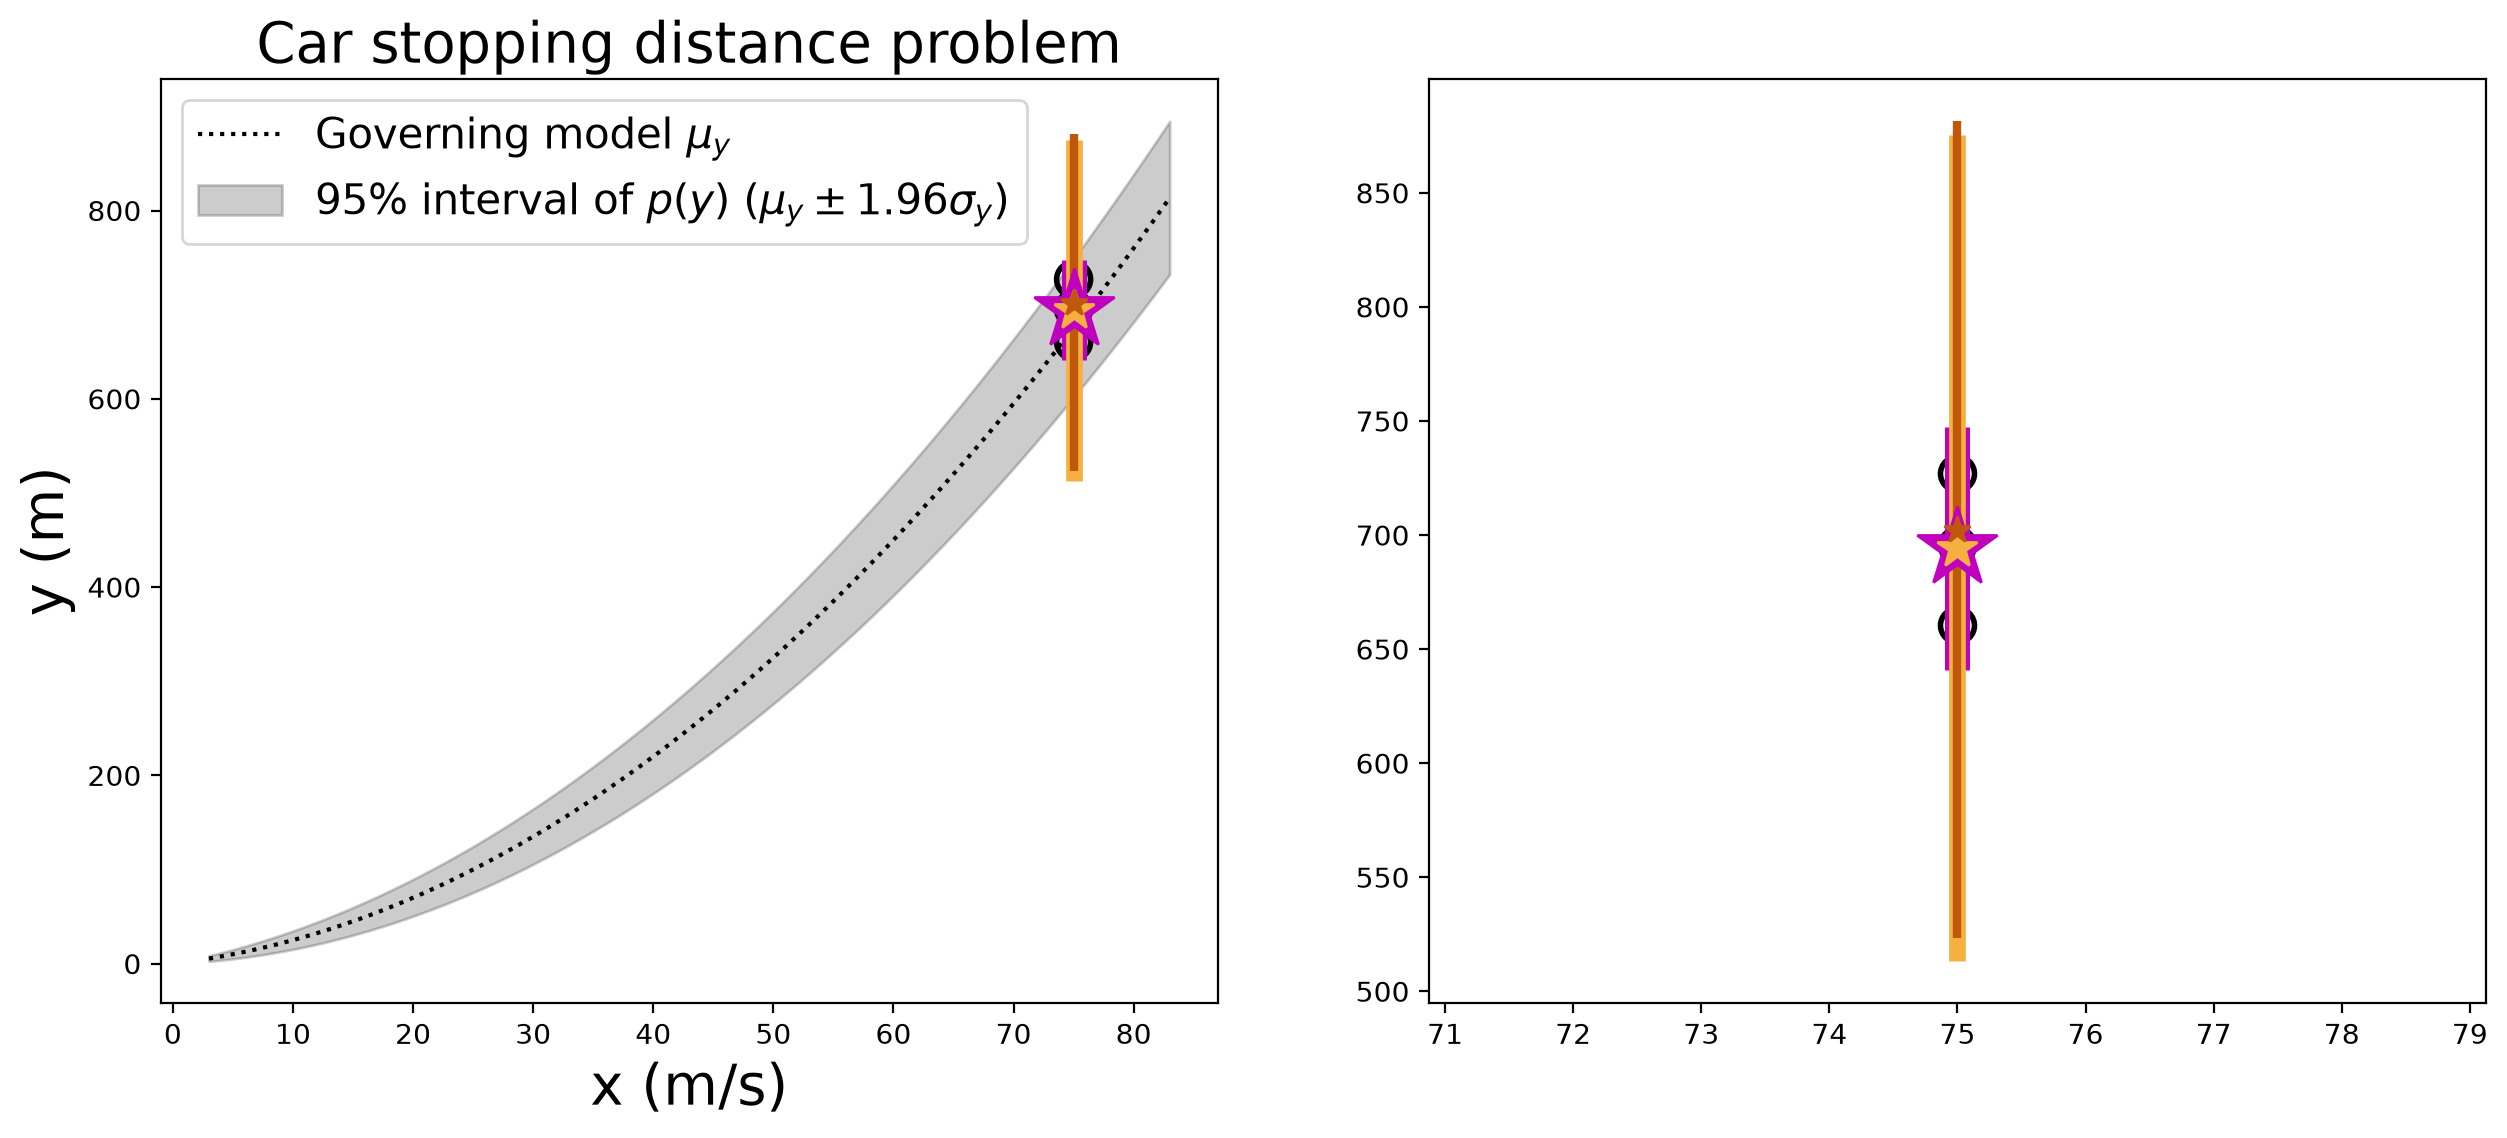

In [5]:
PPD_comparison(N_samples=3) # Plot data and the two PPD's considering different priors

#### Note: the dark orange bar is a different kind of Bayesian interval

The dark orange bar is the 95% **posterior predictive interval** obtained with the Gaussian prior $\mathcal{N}(z|3, 2^2)$. Unlike the light orange bar (Uniform prior), it **no longer coincides with any frequentist interval**, because the prior pulls it:

* its centre moves towards the prediction of the prior mean, $w\,\overset{\scriptscriptstyle <}{\mu}_z + b = 75\times 3 + 562.5 = 787.5$ m;
* it is slightly narrower than the light orange bar, because the informative prior reduces the posterior variance of $z$.

With few data points ($N=3$ above) the pull is visible. As $N \rightarrow \infty$ the two bars coincide (see the slide on the limit $N\rightarrow\infty$): the data overwhelm the prior. A frequentist confidence or prediction interval has no prior, so nothing can pull it; that is precisely what makes the Bayesian intervals useful when data are scarce, and dangerous when the prior is bad.

In [6]:
# Hidden. Closed-form quantities for the interactive plot on the influence of the prior (and its static twin).
# Only two things are computed: the posterior of z (this Lecture) and how the PPD mean behaves over many
# repeated experiments, which we can evaluate here only because we know the "true" p(z) (see the note below).
w_p = 75; b_p = 0.1*75**2; N_p = 3        # x = 75 m/s and N = 3 observations, as in the plot above
mu_z_true = 1.5; sigma_z_true = 0.5       # the "true" p(z): used only to generate data and to evaluate
# Colours follow the equations of Lectures 5-8: prior red, posterior green, PPD orange.
# Light & thin = Uniform prior; dark & thick = Gaussian prior.
col_p = dict(prior='#d62728', post_U='#82E0AA', post_G='#1E8449', ppd_U='#F5B041', ppd_G='#C0580B')

def prior_quality(mu_prior, sigma_prior, sigma_yGz=80, N=N_p):
    """Bias, std and RMSE of the PPD mean mu* over many repeated experiments of N observations."""
    v = (w_p*sigma_z_true)**2/N                   # variance of the empirical mean (true data!)
    r = sigma_yGz**2/(w_p**2*N*sigma_prior**2)    # weight of the prior relative to the data
    d = w_p*(mu_prior - mu_z_true)                # error of the prior mean, in metres
    bias = r*d/(1 + r); std = np.sqrt(v)/(1 + r)
    return dict(r=r, bias=bias, std=std, rmse=np.sqrt(bias**2 + std**2), rmse_uniform=np.sqrt(v),
                tol=sigma_z_true*np.sqrt(2*w_p**2*sigma_prior**2/sigma_yGz**2 + 1/N)) # helps if |mu_prior-1.5|<tol

def ppd_quality(mu_prior, sigma_prior, sigma_yGz=80, N=N_p):
    """Average log-density that the PPD assigns to NEW observations (higher is better), relative to the
    Uniform prior, over many repeated experiments. Differences of this score are differences of KL divergence."""
    q = prior_quality(mu_prior, sigma_prior, sigma_yGz, N)
    s_true2 = (w_p*sigma_z_true)**2                                       # variance of the true p(y)
    s_post2 = 1/(w_p**2*N/sigma_yGz**2 + 1/sigma_prior**2)                # posterior variance of z
    sG2 = sigma_yGz**2 + w_p**2*s_post2; sU2 = sigma_yGz**2*(1 + 1/N)     # PPD variances
    logG = -0.5*np.log(2*np.pi*sG2) - (s_true2 + q['rmse']**2)/(2*sG2)
    logU = -0.5*np.log(2*np.pi*sU2) - (s_true2 + q['rmse_uniform']**2)/(2*sU2)
    A = logG - logU + (q['bias']**2)/(2*sG2)                              # the gain if the prior mean were right
    tol = np.sqrt(2*sG2*np.maximum(A, 0))*(1 + q['r'])/(q['r']*w_p)       # helps if |mu_prior - 1.5| < tol
    return dict(dlog=logG - logU, sigma_G=np.sqrt(sG2), sigma_U=np.sqrt(sU2), tol=tol)

RMSE of mu*, prior N(3,2^2): Monte Carlo 22.07 m, closed form 22.05 m (Uniform prior: 21.65 m)


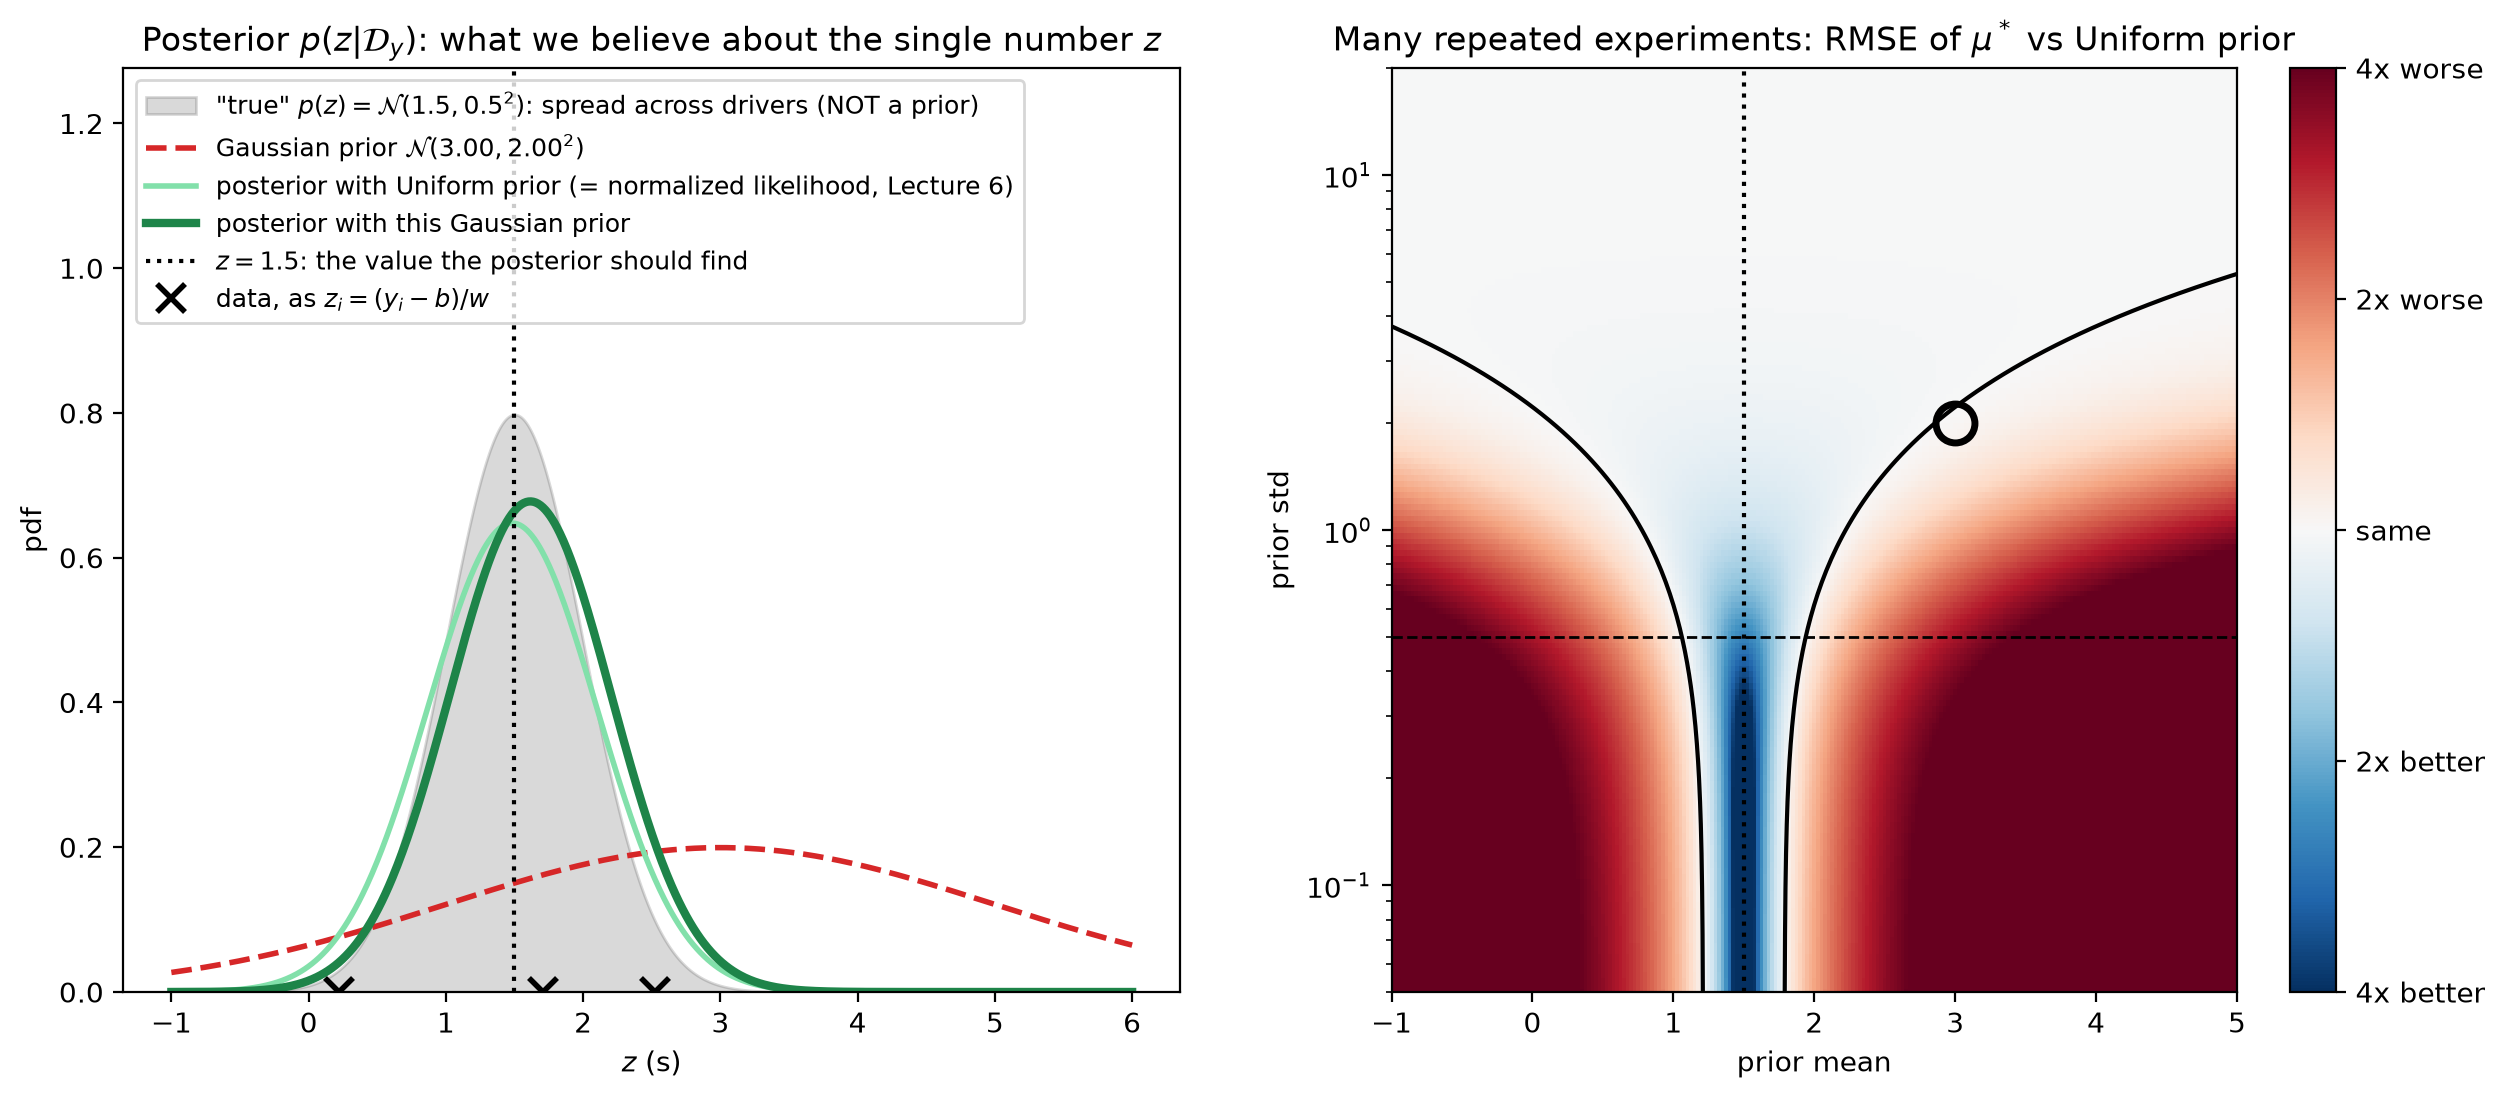

In [7]:
# Hidden in the slides. Static version of the interactive plot below (this is what GitHub, nbviewer and a
# PDF show), drawn for the prior of this Lecture, N(3, 2^2). It also checks the closed form by Monte Carlo.
rng_p = np.random.default_rng(3)
y_p = rng_p.normal(mu_z_true, sigma_z_true, N_p)*w_p + b_p   # ONE dataset of N=3 stopping distances at x=75
sigma_list_p = [0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 7.5, 10, 20] # prior std values of the slider

def prior_panels(mu_prior=3., sigma_prior=2., sigma_yGz=80):
    fig, (axA, axB) = plt.subplots(1, 2, figsize=(15, 6))
    # Panel A: prior, likelihood and posterior of z for this one dataset
    z = np.linspace(-1, 6, 800)
    mu_l = (np.mean(y_p) - b_p)/w_p; s_l = sigma_yGz/(w_p*np.sqrt(N_p))     # Lecture 6 (uniform prior)
    s_post = 1/np.sqrt(1/s_l**2 + 1/sigma_prior**2); mu_post = s_post**2*(mu_l/s_l**2 + mu_prior/sigma_prior**2)
    axA.fill_between(z, norm.pdf(z, mu_z_true, sigma_z_true), color='k', alpha=0.15,
                     label=r'"true" $p(z)=\mathcal{N}(1.5, 0.5^2)$: spread across drivers (NOT a prior)')
    axA.plot(z, norm.pdf(z, mu_prior, sigma_prior), color=col_p['prior'], ls='--', lw=2, label=r'Gaussian prior $\mathcal{N}(%.2f, %.2f^2)$' % (mu_prior, sigma_prior))
    axA.plot(z, norm.pdf(z, mu_l, s_l), color=col_p['post_U'], lw=2, label='posterior with Uniform prior (= normalized likelihood, Lecture 6)')
    axA.plot(z, norm.pdf(z, mu_post, s_post), color=col_p['post_G'], lw=3, label='posterior with this Gaussian prior')
    axA.axvline(mu_z_true, color='k', ls=':', label=r'$z=1.5$: the value the posterior should find')
    axA.plot((y_p - b_p)/w_p, np.zeros(N_p), 'kx', ms=10, mew=2, label=r'data, as $z_i=(y_i-b)/w$')
    axA.set_ylim(0, 1.6*max(norm.pdf(0, 0, v) for v in [sigma_z_true, sigma_prior, s_l, s_post]))
    axA.set_xlabel('$z$ (s)'); axA.set_ylabel('pdf'); axA.legend(fontsize=9, loc='upper left')
    axA.set_title(r'Posterior $p(z|\mathcal{D}_y)$: what we believe about the single number $z$')
    # Panel B: RMSE of the PPD mean over many repeated experiments, relative to the uniform prior
    m = np.linspace(-1, 5, 241); s = np.logspace(np.log10(0.05), np.log10(20), 161)
    M, Sg = np.meshgrid(m, s); q = prior_quality(M, Sg, sigma_yGz)
    cf = axB.pcolormesh(M, Sg, np.clip(np.log2(q['rmse']/q['rmse_uniform']), -2, 2), cmap='RdBu_r', vmin=-2, vmax=2, shading='auto')
    tol = prior_quality(0, s, sigma_yGz)['tol']
    axB.plot(mu_z_true - tol, s, 'k', lw=1.5); axB.plot(mu_z_true + tol, s, 'k', lw=1.5, label='break-even')
    axB.axvline(mu_z_true, color='k', ls=':'); axB.axhline(sigma_z_true, color='k', ls='--', lw=1)
    axB.plot(mu_prior, sigma_prior, 'o', mfc='none', mec='k', ms=14, mew=2.5)
    axB.set_yscale('log'); axB.set_xlim(-1, 5); axB.set_ylim(0.05, 20); axB.set_xlabel('prior mean'); axB.set_ylabel('prior std')
    axB.set_title('Many repeated experiments: RMSE of $\\mu^*$ vs Uniform prior')
    cb = fig.colorbar(cf, ax=axB, ticks=[-2, -1, 0, 1, 2])
    cb.ax.set_yticklabels(['4x better', '2x better', 'same', '2x worse', '4x worse'])
    plt.close(fig)
    return fig

# Monte Carlo check of the closed form for the prior of this Lecture:
_R = 200_000; _ybar = (np.random.default_rng(0).normal(mu_z_true, sigma_z_true, (_R, N_p))*w_p + b_p).mean(axis=1)
_s2 = 80**2/(w_p**2*N_p); _mu_post = ((_ybar - b_p)/w_p*2.**2 + 3.*_s2)/(2.**2 + _s2)
_q = prior_quality(3., 2.)
print("RMSE of mu*, prior N(3,2^2): Monte Carlo %.2f m, closed form %.2f m (Uniform prior: %.2f m)"
      % (np.sqrt(np.mean((_mu_post*w_p + b_p - (1.5*w_p + b_p))**2)), _q['rmse'], _q['rmse_uniform']))
prior_panels()

In [8]:
# Hidden. Interactive version of the plot above. The slider changes the prior, i.e. the model, so the
# closed-form posterior and prior_quality() have to live in the renderer (a few lines, same formulas).
# The dataset y_p is handed over from the static cell. Pattern documented in Lectures/INTERACTIVE_PLOTS.md
import json as _json
from IPython.display import HTML
_data = dict(y=[round(float(v), 6) for v in y_p], w=w_p, b=b_p, N=N_p, mz=mu_z_true, sz=sigma_z_true,
             syz=80.0, syz_true=w_p*sigma_z_true, sig=sigma_list_p, sig_start=sigma_list_p.index(2),
             col=col_p, mlo=-1.0, mhi=5.0, mstep=0.05, mstart=3.0, zlo=-1.0, zhi=6.0)
_prior_plot = HTML(r'''<div id="__ID__-w" style="font-family:system-ui,sans-serif;max-width:__W__px">
<canvas id="__ID__-c" width="__CW__" height="__CH__" style="width:100%;max-width:__W__px;aspect-ratio:__W__/__H__"></canvas>
<div style="display:flex;gap:26px;flex-wrap:wrap;align-items:center;font-size:14px;margin-top:4px">
 <label style="display:inline-flex;align-items:center;gap:6px">prior mean
   <input id="__ID__-m" type="range" style="width:220px"><span id="__ID__-mv" style="min-width:40px"></span></label>
 <label style="display:inline-flex;align-items:center;gap:6px">prior std
   <input id="__ID__-s" type="range" style="width:220px"><span id="__ID__-sv" style="min-width:40px"></span></label>
 <label style="display:inline-flex;align-items:center;gap:6px"><input id="__ID__-k" type="checkbox">
   correct observation distribution: &sigma;<sub>y|z</sub> = w&sigma;<sub>z</sub> = 37.5 m (instead of our 80 m)</label>
</div>
<div id="__ID__-leg" style="font-size:13px;line-height:1.7;margin-top:6px"></div>
</div>
<script>
(function(){
 // D.y is the dataset from the notebook. The formulas below are the posterior of this Lecture and
 // prior_quality() from the notebook: they must be live because the sliders change the prior.
 var D=__DATA__, S=2;
 var c=document.getElementById('__ID__-c'), g=c.getContext('2d');
 var sm=document.getElementById('__ID__-m'), ss=document.getElementById('__ID__-s'), ck=document.getElementById('__ID__-k');
 var W=c.width, H=c.height;
 var A={l:58*S, r:W/2-24*S, t:34*S, b:H-44*S}, B={l:W/2+60*S, r:W-92*S, t:34*S, b:H-44*S};
 var slo=Math.log10(D.sig[0]), shi=Math.log10(D.sig[D.sig.length-1]);
 sm.min=D.mlo; sm.max=D.mhi; sm.step=D.mstep; sm.value=D.mstart;
 ss.min=0; ss.max=D.sig.length-1; ss.step=1; ss.value=D.sig_start;
 var N=D.N, w=D.w, b=D.b, ybar=0; for(var i=0;i<N;i++) ybar+=D.y[i]/N;
 function npdf(x,m,s){var u=(x-m)/s; return Math.exp(-0.5*u*u)/(s*Math.sqrt(2*Math.PI));}
 function Phi(x){ // standard normal cdf (Abramowitz & Stegun 7.1.26)
   var t=1/(1+0.3275911*Math.abs(x)/Math.SQRT2);
   var e=1-(((((1.061405429*t-1.453152027)*t)+1.421413741)*t-0.284496736)*t+0.254829592)*t*Math.exp(-x*x/2);
   return x>=0 ? 0.5*(1+e) : 0.5*(1-e);}
 function quality(mp,sp,syz){ // same as prior_quality() in the notebook
   var v=Math.pow(w*D.sz,2)/N, r=syz*syz/(w*w*N*sp*sp), d=w*(mp-D.mz), bias=r*d/(1+r), sd=Math.sqrt(v)/(1+r);
   return {v:v, r:r, d:d, bias:bias, sd:sd, rmse:Math.hypot(bias,sd), ru:Math.sqrt(v),
           tol:D.sz*Math.sqrt(2*w*w*sp*sp/(syz*syz)+1/N)};}
 function pbeat(q){ // P(|error with prior| < |error with Uniform prior|) in ONE experiment
   if(Math.abs(q.d)<1e-9) return 1;
   var r1=q.d, r2=-q.d*q.r/(2+q.r), lo=Math.min(r1,r2), hi=Math.max(r1,r2), s=Math.sqrt(q.v);
   return Phi(lo/s)+1-Phi(hi/s);}
 function txt(s,x,y,col,al,sz,bold){g.save();g.fillStyle=col||'#333';g.textAlign=al||'center';
   g.font=(bold?'bold ':'')+((sz||12)*S)+'px system-ui';g.fillText(s,x,y);g.restore();}
 function line(pts,col,lw,dash){g.save();g.strokeStyle=col;g.lineWidth=lw*S;if(dash)g.setLineDash(dash.map(function(v){return v*S;}));
   g.beginPath();for(var i=0;i<pts.length;i++){if(i)g.lineTo(pts[i][0],pts[i][1]);else g.moveTo(pts[i][0],pts[i][1]);}g.stroke();g.restore();}
 function frame(P){g.save();g.strokeStyle='#999';g.lineWidth=1*S;g.strokeRect(P.l,P.t,P.r-P.l,P.b-P.t);g.restore();}
 // Panel B helpers: x = prior mean, y = log10(prior std)
 function BX(m){return B.l+(m-D.mlo)/(D.mhi-D.mlo)*(B.r-B.l);}
 function BY(s){return B.b-(Math.log10(s)-slo)/(shi-slo)*(B.b-B.t);}
 function col(t){ // t = log2(RMSE ratio) in [-2,2]: blue = prior helps, red = prior hurts
   t=Math.max(-2,Math.min(2,t))/2; var c0=[247,247,247], c1=t<0?[33,102,172]:[178,24,43], a=Math.abs(t);
   return 'rgb('+[0,1,2].map(function(k){return Math.round(c0[k]+(c1[k]-c0[k])*a);}).join(',')+')';}
 var cache={};
 function heat(syz){ // the heat map only depends on sigma_y|z: draw it once per value, off screen
   if(cache[syz]) return cache[syz];
   var o=document.createElement('canvas'); o.width=W; o.height=H; var h=o.getContext('2d');
   var nx=150, ny=100, dx=(B.r-B.l)/nx, dy=(B.b-B.t)/ny;
   for(var i=0;i<nx;i++) for(var j=0;j<ny;j++){
     var m=D.mlo+(i+0.5)/nx*(D.mhi-D.mlo), s=Math.pow(10, slo+(j+0.5)/ny*(shi-slo)), q=quality(m,s,syz);
     h.fillStyle=col(Math.log2(q.rmse/q.ru)); h.fillRect(B.l+i*dx, B.b-(j+1)*dy, dx+1, dy+1);}
   return cache[syz]=o;}
 function draw(){
  var mp=+sm.value, sp=D.sig[+ss.value], syz=ck.checked?D.syz_true:D.syz;
  document.getElementById('__ID__-mv').textContent=mp.toFixed(2);
  document.getElementById('__ID__-sv').textContent=sp;
  g.clearRect(0,0,W,H);
  // ---------- Panel A: one experiment, in z-space
  var mu=(ybar-b)/w, sl=syz/(w*Math.sqrt(N));                       // Lecture 6 posterior (Uniform prior)
  var spo=1/Math.sqrt(1/(sl*sl)+1/(sp*sp)), mpo=spo*spo*(mu/(sl*sl)+mp/(sp*sp)); // this Lecture
  var ymax=1.12*Math.max(npdf(0,0,D.sz), npdf(0,0,sp), npdf(0,0,sl), npdf(0,0,spo));
  function AX(z){return A.l+(z-D.zlo)/(D.zhi-D.zlo)*(A.r-A.l);} function AY(p){return A.b-p/ymax*(A.b-A.t);}
  var n=500, zs=[]; for(var i=0;i<=n;i++) zs.push(D.zlo+(D.zhi-D.zlo)*i/n);
  g.save(); g.fillStyle='rgba(0,0,0,0.13)'; g.beginPath(); g.moveTo(AX(D.zlo),AY(0));
  zs.forEach(function(z){g.lineTo(AX(z),AY(npdf(z,D.mz,D.sz)));}); g.lineTo(AX(D.zhi),AY(0)); g.fill(); g.restore();
  line([[AX(D.mz),A.t],[AX(D.mz),A.b]],'#000',1.3,[2,3]);
  line(zs.map(function(z){return [AX(z),AY(npdf(z,mp,sp))];}),D.col.prior,2.2,[7,4]);
  line(zs.map(function(z){return [AX(z),AY(npdf(z,mu,sl))];}),D.col.post_U,2.2);
  line(zs.map(function(z){return [AX(z),AY(npdf(z,mpo,spo))];}),D.col.post_G,3.2);
  g.save(); g.strokeStyle='#000'; g.lineWidth=2*S;
  D.y.forEach(function(y){var X=AX((y-b)/w), Y=A.b-8*S; g.beginPath(); g.moveTo(X-5*S,Y-5*S); g.lineTo(X+5*S,Y+5*S);
    g.moveTo(X+5*S,Y-5*S); g.lineTo(X-5*S,Y+5*S); g.stroke();}); g.restore();
  frame(A);
  for(var z=Math.ceil(D.zlo); z<=D.zhi; z++) txt(z.toFixed(0),AX(z),A.b+16*S,'#555','center',11);
  txt('z  (s)',(A.l+A.r)/2,A.b+34*S,'#333','center',12);
  txt('pdf',A.l-30*S,(A.t+A.b)/2,'#333','center',12);
  txt('Posterior p(z|D): what we believe about the single number z (N = 3)',(A.l+A.r)/2,A.t-12*S,'#222','center',12.5,true);
  // ---------- Panel B: many repeated experiments
  g.drawImage(heat(syz),0,0);
  var sg=[]; for(var j=0;j<=120;j++) sg.push(Math.pow(10, slo+(shi-slo)*j/120));
  [-1,1].forEach(function(sgn){ line(sg.map(function(s){var m=D.mz+sgn*quality(0,s,syz).tol;
      return [BX(Math.max(D.mlo,Math.min(D.mhi,m))),BY(s)];}),'#000',1.8); });
  line([[BX(D.mz),B.t],[BX(D.mz),B.b]],'#000',1.2,[2,3]);
  line([[B.l,BY(D.sz)],[B.r,BY(D.sz)]],'#000',1,[6,4]);
  txt('prior std = 0.5 = std of the "true" p(z): no special status',B.r-6*S,BY(D.sz)+14*S,'#000','right',10.5);
  g.save(); g.strokeStyle='#000'; g.lineWidth=3*S; g.beginPath(); g.arc(BX(mp),BY(sp),9*S,0,7); g.stroke();
  g.strokeStyle='#fff'; g.lineWidth=1.2*S; g.beginPath(); g.arc(BX(mp),BY(sp),9*S,0,7); g.stroke(); g.restore();
  frame(B);
  for(var m=Math.ceil(D.mlo); m<=D.mhi; m++) txt(m.toFixed(0),BX(m),B.b+16*S,'#555','center',11);
  [0.05,0.1,0.2,0.5,1,2,5,10,20].forEach(function(s){txt(String(s),B.l-6*S,BY(s)+4*S,'#555','right',11);});
  txt('prior mean',(B.l+B.r)/2,B.b+34*S,'#333','center',12);
  g.save(); g.translate(B.l-40*S,(B.t+B.b)/2); g.rotate(-Math.PI/2); txt('prior std  (log scale)',0,0,'#333','center',12); g.restore();
  txt('Many repeated experiments: RMSE of μ* relative to the Uniform prior',(B.l+B.r)/2,B.t-12*S,'#222','center',12.5,true);
  txt('↑ wider prior → Uniform prior',B.r-6*S,B.t+14*S,'#000','right',10.5);
  // colour bar
  var cx=B.r+16*S, cw=14*S;
  for(var k=0;k<100;k++){g.fillStyle=col(2-4*k/99); g.fillRect(cx,B.t+k*(B.b-B.t)/100,cw,(B.b-B.t)/100+1);}
  g.save();g.strokeStyle='#999';g.lineWidth=1*S;g.strokeRect(cx,B.t,cw,B.b-B.t);g.restore();
  [['4× worse',0],['2× worse',0.25],['same',0.5],['2× better',0.75],['4× better',1]].forEach(function(p){
    txt(p[0],cx+cw+4*S,B.t+p[1]*(B.b-B.t)+4*S,'#333','left',10);});
  // ---------- read-out
  var q=quality(mp,sp,syz), pull=q.r/(1+q.r), mustar=w*mpo+b, sstar=Math.sqrt(syz*syz+w*w*spo*spo);
  var helps=q.rmse<q.ru, truth=w*D.mz+b;
  document.getElementById('__ID__-leg').innerHTML=
   '<span style="color:#888">&#9632;</span> &ldquo;true&rdquo; p(z) = N(1.5, 0.5&sup2;): how reaction times vary <i>across drivers</i>. Not a prior! Our model puts this spread in &sigma;<sub>y|z</sub>. '+
   '&nbsp; <span style="color:'+D.col.prior+'">&#9476;&#9476;</span> Gaussian prior &nbsp; <span style="color:'+D.col.post_U+'">&#8212;</span> posterior with Uniform prior (= normalized likelihood, Lecture 6) &nbsp; '+
   '<span style="color:'+D.col.post_G+';font-weight:bold">&#8212;</span> posterior with this Gaussian prior &nbsp; &#10005; data as z<sub>i</sub> = (y<sub>i</sub>&minus;b)/w &nbsp; &#8942; z = 1.5, the value the posterior should find<br>'+
   '<b>This experiment:</b> the prior pulls the prediction <b>'+(100*pull).toFixed(1)+'%</b> of the way from the data towards the prior&rsquo;s prediction ('+(w*mp+b).toFixed(0)+' m). '+
   'PPD: &mu;* = '+mustar.toFixed(1)+' m (Uniform prior: '+ybar.toFixed(1)+' m; truth: '+truth.toFixed(0)+' m), '+
   '&sigma;* = '+sstar.toFixed(1)+' m (Uniform prior: '+(syz*Math.sqrt(1+1/N)).toFixed(1)+' m; truth: 37.5 m).<br>'+
   '<b>Many experiments:</b> RMSE of &mu;* = <b>'+q.rmse.toFixed(1)+' m</b> (bias '+q.bias.toFixed(1)+', std '+q.sd.toFixed(1)+') vs Uniform prior '+q.ru.toFixed(1)+' m &rarr; '+
   (helps?'<b style="color:#2166ac">the prior helps</b>':'<b style="color:#b2182b">the prior hurts</b>')+
   '. It helps if |prior mean &minus; 1.5| &lt; '+q.tol.toFixed(2)+'. Chance it beats the Uniform prior in a <i>single</i> experiment: <b>'+(100*pbeat(q)).toFixed(0)+'%</b>.';
 }
 sm.addEventListener('input',draw); ss.addEventListener('input',draw); ck.addEventListener('change',draw); draw();
})();
</script>
'''
    .replace('__DATA__', _json.dumps(_data))
    .replace('__ID__', 'p7')
    .replace('__W__', '1000').replace('__H__', '430')
    .replace('__CW__', '2000').replace('__CH__', '860'))

### How much should we trust the prior?

Left: what one experiment tells us about $z$. Right: the same prior judged over many repeated experiments (possible only because here we know the truth). See the note below.

In [9]:
_prior_plot

PPD gain with prior N(3,2^2): Monte Carlo +0.0075 nats, closed form +0.0075 nats


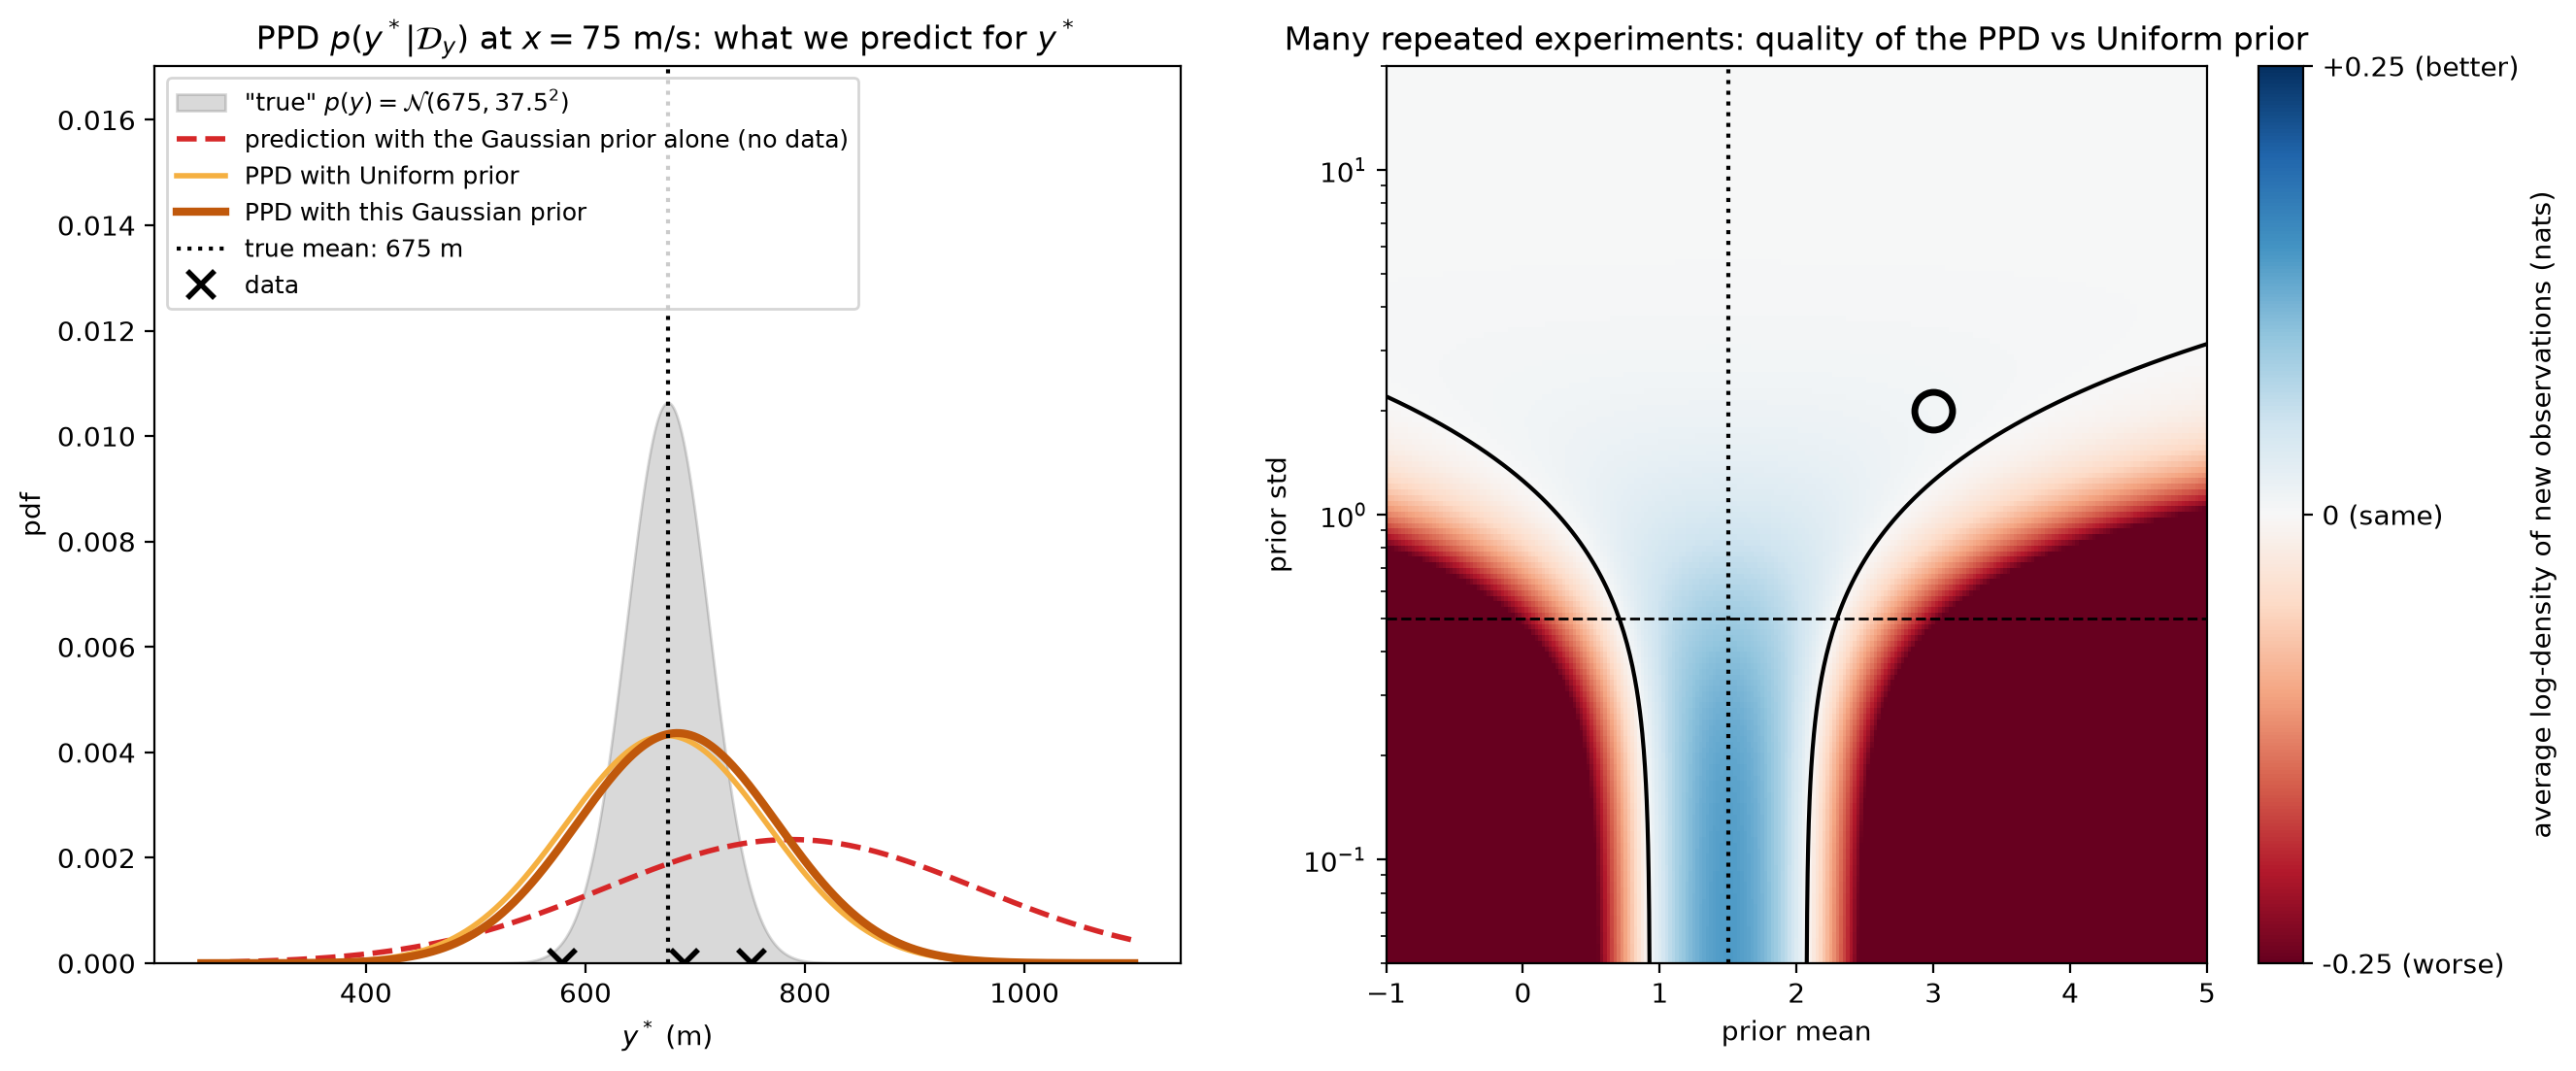

In [10]:
# Hidden in the slides. Static version of the interactive PPD plot below, for the prior of this Lecture,
# N(3, 2^2), and the same dataset y_p as above. It also checks ppd_quality() by Monte Carlo.
def ppd_panels(mu_prior=3., sigma_prior=2., sigma_yGz=80):
    fig, (axA, axB) = plt.subplots(1, 2, figsize=(15, 6))
    # Panel A: the PPDs for this one dataset, compared with the true p(y) at x = 75
    y = np.linspace(250, 1100, 800); truth = mu_z_true*w_p + b_p
    s_l2 = sigma_yGz**2/(w_p**2*N_p); mu_l = (np.mean(y_p) - b_p)/w_p
    s_post2 = 1/(1/s_l2 + 1/sigma_prior**2); mu_post = s_post2*(mu_l/s_l2 + mu_prior/sigma_prior**2)
    axA.fill_between(y, norm.pdf(y, truth, w_p*sigma_z_true), color='k', alpha=0.15, label=r'"true" $p(y)=\mathcal{N}(675, 37.5^2)$')
    axA.plot(y, norm.pdf(y, w_p*mu_prior + b_p, np.sqrt(sigma_yGz**2 + w_p**2*sigma_prior**2)), color=col_p['prior'], ls='--', lw=2,
             label='prediction with the Gaussian prior alone (no data)')
    axA.plot(y, norm.pdf(y, np.mean(y_p), sigma_yGz*np.sqrt(1 + 1/N_p)), color=col_p['ppd_U'], lw=2, label='PPD with Uniform prior')
    axA.plot(y, norm.pdf(y, w_p*mu_post + b_p, np.sqrt(sigma_yGz**2 + w_p**2*s_post2)), color=col_p['ppd_G'], lw=3, label='PPD with this Gaussian prior')
    axA.axvline(truth, color='k', ls=':', label='true mean: 675 m')
    axA.plot(y_p, np.zeros(N_p), 'kx', ms=10, mew=2, label='data')
    axA.set_ylim(0, 1.6*norm.pdf(0, 0, w_p*sigma_z_true))
    axA.set_xlabel('$y^*$ (m)'); axA.set_ylabel('pdf'); axA.legend(fontsize=9, loc='upper left')
    axA.set_title(r'PPD $p(y^*|\mathcal{D}_y)$ at $x=75$ m/s: what we predict for $y^*$')
    # Panel B: average log-density of new observations, relative to the Uniform prior
    m = np.linspace(-1, 5, 241); s = np.logspace(np.log10(0.05), np.log10(20), 161)
    M, Sg = np.meshgrid(m, s); q = ppd_quality(M, Sg, sigma_yGz)
    cf = axB.pcolormesh(M, Sg, np.clip(q['dlog'], -0.25, 0.25), cmap='RdBu', vmin=-0.25, vmax=0.25, shading='auto')
    tol = ppd_quality(0, s, sigma_yGz)['tol']
    axB.plot(mu_z_true - tol, s, 'k', lw=1.5); axB.plot(mu_z_true + tol, s, 'k', lw=1.5)
    axB.axvline(mu_z_true, color='k', ls=':'); axB.axhline(sigma_z_true, color='k', ls='--', lw=1)
    axB.plot(mu_prior, sigma_prior, 'o', mfc='none', mec='k', ms=14, mew=2.5)
    axB.set_yscale('log'); axB.set_xlim(-1, 5); axB.set_ylim(0.05, 20)
    axB.set_xlabel('prior mean'); axB.set_ylabel('prior std')
    axB.set_title('Many repeated experiments: quality of the PPD vs Uniform prior')
    cb = fig.colorbar(cf, ax=axB, ticks=[-0.25, 0, 0.25])
    cb.ax.set_yticklabels(['-0.25 (worse)', '0 (same)', '+0.25 (better)'])
    cb.set_label('average log-density of new observations (nats)')
    plt.close(fig)
    return fig

# Monte Carlo check of ppd_quality() for the prior of this Lecture (new observations y_new from the true p(y)):
_rng = np.random.default_rng(1); _ybar = (_rng.normal(mu_z_true, sigma_z_true, (_R, N_p))*w_p + b_p).mean(axis=1)
_y_new = _rng.normal(mu_z_true, sigma_z_true, _R)*w_p + b_p
_mu_post = ((_ybar - b_p)/w_p*2.**2 + 3.*_s2)/(2.**2 + _s2); _qp = ppd_quality(3., 2.)
_dlog_mc = np.mean(norm.logpdf(_y_new, _mu_post*w_p + b_p, _qp['sigma_G']) - norm.logpdf(_y_new, _ybar, _qp['sigma_U']))
print("PPD gain with prior N(3,2^2): Monte Carlo %+.4f nats, closed form %+.4f nats" % (_dlog_mc, _qp['dlog']))
ppd_panels()

In [11]:
# Hidden. Interactive version of the PPD plot above. The slider changes the prior, i.e. the model, so the
# closed-form posterior, prior_quality() and ppd_quality() have to live in the renderer (same formulas).
# The dataset y_p is handed over from the static cell. Pattern documented in Lectures/INTERACTIVE_PLOTS.md
import json as _json
from IPython.display import HTML
_data = dict(y=[round(float(v), 6) for v in y_p], w=w_p, b=b_p, N=N_p, mz=mu_z_true, sz=sigma_z_true,
             syz=80.0, syz_true=w_p*sigma_z_true, sig=sigma_list_p, sig_start=sigma_list_p.index(2),
             col=col_p, mlo=-1.0, mhi=5.0, mstep=0.05, mstart=3.0, zlo=-1.0, zhi=6.0, ylo=250.0, yhi=1100.0)
_ppd_plot = HTML(r'''<div id="__ID__-w" style="font-family:system-ui,sans-serif;max-width:__W__px">
<canvas id="__ID__-c" width="__CW__" height="__CH__" style="width:100%;max-width:__W__px;aspect-ratio:__W__/__H__"></canvas>
<div style="display:flex;gap:26px;flex-wrap:wrap;align-items:center;font-size:14px;margin-top:4px">
 <label style="display:inline-flex;align-items:center;gap:6px">prior mean
   <input id="__ID__-m" type="range" style="width:220px"><span id="__ID__-mv" style="min-width:40px"></span></label>
 <label style="display:inline-flex;align-items:center;gap:6px">prior std
   <input id="__ID__-s" type="range" style="width:220px"><span id="__ID__-sv" style="min-width:40px"></span></label>
 <label style="display:inline-flex;align-items:center;gap:6px"><input id="__ID__-k" type="checkbox">
   correct observation distribution: &sigma;<sub>y|z</sub> = w&sigma;<sub>z</sub> = 37.5 m (instead of our 80 m)</label>
</div>
<div id="__ID__-leg" style="font-size:13px;line-height:1.7;margin-top:6px"></div>
</div>
<script>
(function(){
 // D.y is the dataset from the notebook. The formulas below are the posterior of this Lecture and
 // prior_quality() from the notebook: they must be live because the sliders change the prior.
 var D=__DATA__, S=2;
 var c=document.getElementById('__ID__-c'), g=c.getContext('2d');
 var sm=document.getElementById('__ID__-m'), ss=document.getElementById('__ID__-s'), ck=document.getElementById('__ID__-k');
 var W=c.width, H=c.height;
 var A={l:58*S, r:W/2-24*S, t:34*S, b:H-44*S}, B={l:W/2+60*S, r:W-92*S, t:34*S, b:H-44*S};
 var slo=Math.log10(D.sig[0]), shi=Math.log10(D.sig[D.sig.length-1]);
 sm.min=D.mlo; sm.max=D.mhi; sm.step=D.mstep; sm.value=D.mstart;
 ss.min=0; ss.max=D.sig.length-1; ss.step=1; ss.value=D.sig_start;
 var N=D.N, w=D.w, b=D.b, ybar=0; for(var i=0;i<N;i++) ybar+=D.y[i]/N;
 function npdf(x,m,s){var u=(x-m)/s; return Math.exp(-0.5*u*u)/(s*Math.sqrt(2*Math.PI));}
 function Phi(x){ // standard normal cdf (Abramowitz & Stegun 7.1.26)
   var t=1/(1+0.3275911*Math.abs(x)/Math.SQRT2);
   var e=1-(((((1.061405429*t-1.453152027)*t)+1.421413741)*t-0.284496736)*t+0.254829592)*t*Math.exp(-x*x/2);
   return x>=0 ? 0.5*(1+e) : 0.5*(1-e);}
 function quality(mp,sp,syz){ // same as prior_quality() in the notebook
   var v=Math.pow(w*D.sz,2)/N, r=syz*syz/(w*w*N*sp*sp), d=w*(mp-D.mz), bias=r*d/(1+r), sd=Math.sqrt(v)/(1+r);
   return {v:v, r:r, d:d, bias:bias, sd:sd, rmse:Math.hypot(bias,sd), ru:Math.sqrt(v),
           tol:D.sz*Math.sqrt(2*w*w*sp*sp/(syz*syz)+1/N)};}
 function pbeat(q){ // P(|error with prior| < |error with Uniform prior|) in ONE experiment
   if(Math.abs(q.d)<1e-9) return 1;
   var r1=q.d, r2=-q.d*q.r/(2+q.r), lo=Math.min(r1,r2), hi=Math.max(r1,r2), s=Math.sqrt(q.v);
   return Phi(lo/s)+1-Phi(hi/s);}
 function txt(s,x,y,col,al,sz,bold){g.save();g.fillStyle=col||'#333';g.textAlign=al||'center';
   g.font=(bold?'bold ':'')+((sz||12)*S)+'px system-ui';g.fillText(s,x,y);g.restore();}
 function line(pts,col,lw,dash){g.save();g.strokeStyle=col;g.lineWidth=lw*S;if(dash)g.setLineDash(dash.map(function(v){return v*S;}));
   g.beginPath();for(var i=0;i<pts.length;i++){if(i)g.lineTo(pts[i][0],pts[i][1]);else g.moveTo(pts[i][0],pts[i][1]);}g.stroke();g.restore();}
 function frame(P){g.save();g.strokeStyle='#999';g.lineWidth=1*S;g.strokeRect(P.l,P.t,P.r-P.l,P.b-P.t);g.restore();}
 // Panel B helpers: x = prior mean, y = log10(prior std)
 function BX(m){return B.l+(m-D.mlo)/(D.mhi-D.mlo)*(B.r-B.l);}
 function BY(s){return B.b-(Math.log10(s)-slo)/(shi-slo)*(B.b-B.t);}
 function col(t){ // t = log2(RMSE ratio) in [-2,2]: blue = prior helps, red = prior hurts
   t=Math.max(-2,Math.min(2,t))/2; var c0=[247,247,247], c1=t<0?[33,102,172]:[178,24,43], a=Math.abs(t);
   return 'rgb('+[0,1,2].map(function(k){return Math.round(c0[k]+(c1[k]-c0[k])*a);}).join(',')+')';}
 function ppdq(mp,sp,syz){ // same as ppd_quality() in the notebook
   var q=quality(mp,sp,syz), st2=Math.pow(w*D.sz,2), spo2=1/(w*w*N/(syz*syz)+1/(sp*sp));
   var sG2=syz*syz+w*w*spo2, sU2=syz*syz*(1+1/N);
   var lG=-0.5*Math.log(2*Math.PI*sG2)-(st2+q.rmse*q.rmse)/(2*sG2), lU=-0.5*Math.log(2*Math.PI*sU2)-(st2+q.ru*q.ru)/(2*sU2);
   var A=lG-lU+q.bias*q.bias/(2*sG2);
   return {q:q, dlog:lG-lU, sG:Math.sqrt(sG2), sU:Math.sqrt(sU2), tol:Math.sqrt(2*sG2*Math.max(A,0))*(1+q.r)/(q.r*w)};}
 function colp(t){ // t = gain in nats, clipped to [-0.25,0.25]: blue = prior helps, red = prior hurts
   return col(-8*Math.max(-0.25,Math.min(0.25,t)));}
 var cache={};
 function heat(syz){ // the heat map only depends on sigma_y|z: draw it once per value, off screen
   if(cache[syz]) return cache[syz];
   var o=document.createElement('canvas'); o.width=W; o.height=H; var h=o.getContext('2d');
   var nx=150, ny=100, dx=(B.r-B.l)/nx, dy=(B.b-B.t)/ny;
   for(var i=0;i<nx;i++) for(var j=0;j<ny;j++){
     var m=D.mlo+(i+0.5)/nx*(D.mhi-D.mlo), s=Math.pow(10, slo+(j+0.5)/ny*(shi-slo)), q=null;
     h.fillStyle=colp(ppdq(m,s,syz).dlog); h.fillRect(B.l+i*dx, B.b-(j+1)*dy, dx+1, dy+1);}
   return cache[syz]=o;}
 function draw(){
  var mp=+sm.value, sp=D.sig[+ss.value], syz=ck.checked?D.syz_true:D.syz;
  document.getElementById('__ID__-mv').textContent=mp.toFixed(2);
  document.getElementById('__ID__-sv').textContent=sp;
  g.clearRect(0,0,W,H);
  // ---------- Panel A: one experiment, the PPD in y-space
  var mu=(ybar-b)/w, sl=syz/(w*Math.sqrt(N));
  var spo=1/Math.sqrt(1/(sl*sl)+1/(sp*sp)), mpo=spo*spo*(mu/(sl*sl)+mp/(sp*sp));
  var truth=w*D.mz+b, sT=w*D.sz, mG=w*mpo+b, sG=Math.sqrt(syz*syz+w*w*spo*spo), sU=syz*Math.sqrt(1+1/N);
  var mP=w*mp+b, sP=Math.sqrt(syz*syz+w*w*sp*sp);                                 // prior alone (no data)
  var ymax=1.6*npdf(0,0,sT);
  function AX(y){return A.l+(y-D.ylo)/(D.yhi-D.ylo)*(A.r-A.l);} function AY(p){return A.b-Math.min(p,ymax)/ymax*(A.b-A.t);}
  var n=500, ys=[]; for(var i=0;i<=n;i++) ys.push(D.ylo+(D.yhi-D.ylo)*i/n);
  g.save(); g.fillStyle='rgba(0,0,0,0.13)'; g.beginPath(); g.moveTo(AX(D.ylo),AY(0));
  ys.forEach(function(y){g.lineTo(AX(y),AY(npdf(y,truth,sT)));}); g.lineTo(AX(D.yhi),AY(0)); g.fill(); g.restore();
  line([[AX(truth),A.t],[AX(truth),A.b]],'#000',1.3,[2,3]);
  line(ys.map(function(y){return [AX(y),AY(npdf(y,mP,sP))];}),D.col.prior,2.2,[7,4]);
  line(ys.map(function(y){return [AX(y),AY(npdf(y,ybar,sU))];}),D.col.ppd_U,2.2);
  line(ys.map(function(y){return [AX(y),AY(npdf(y,mG,sG))];}),D.col.ppd_G,3.2);
  g.save(); g.strokeStyle='#000'; g.lineWidth=2*S;
  D.y.forEach(function(y){var X=AX(y), Y=A.b-8*S; g.beginPath(); g.moveTo(X-5*S,Y-5*S); g.lineTo(X+5*S,Y+5*S);
    g.moveTo(X+5*S,Y-5*S); g.lineTo(X-5*S,Y+5*S); g.stroke();}); g.restore();
  frame(A);
  for(var y=300; y<=D.yhi; y+=100) txt(y.toFixed(0),AX(y),A.b+16*S,'#555','center',11);
  txt('y*  (m)',(A.l+A.r)/2,A.b+34*S,'#333','center',12);
  txt('pdf',A.l-30*S,(A.t+A.b)/2,'#333','center',12);
  txt('PPD p(y*|D) at x = 75 m/s: what we predict for y* (N = 3)',(A.l+A.r)/2,A.t-12*S,'#222','center',12.5,true);
  // ---------- Panel B: many repeated experiments
  g.drawImage(heat(syz),0,0);
  var sg=[]; for(var j=0;j<=120;j++) sg.push(Math.pow(10, slo+(shi-slo)*j/120));
  [-1,1].forEach(function(sgn){ var pts=[]; sg.forEach(function(s){var t=ppdq(0,s,syz).tol; if(t>0){var m=D.mz+sgn*t;
      pts.push([BX(Math.max(D.mlo,Math.min(D.mhi,m))),BY(s)]);}}); if(pts.length>1) line(pts,'#000',1.8); });
  line([[BX(D.mz),B.t],[BX(D.mz),B.b]],'#000',1.2,[2,3]);
  line([[B.l,BY(D.sz)],[B.r,BY(D.sz)]],'#000',1,[6,4]);
  txt('prior std = 0.5 = std of the "true" p(z): no special status',B.r-6*S,BY(D.sz)+14*S,'#000','right',10.5);
  g.save(); g.strokeStyle='#000'; g.lineWidth=3*S; g.beginPath(); g.arc(BX(mp),BY(sp),9*S,0,7); g.stroke();
  g.strokeStyle='#fff'; g.lineWidth=1.2*S; g.beginPath(); g.arc(BX(mp),BY(sp),9*S,0,7); g.stroke(); g.restore();
  frame(B);
  for(var m=Math.ceil(D.mlo); m<=D.mhi; m++) txt(m.toFixed(0),BX(m),B.b+16*S,'#555','center',11);
  [0.05,0.1,0.2,0.5,1,2,5,10,20].forEach(function(s){txt(String(s),B.l-6*S,BY(s)+4*S,'#555','right',11);});
  txt('prior mean',(B.l+B.r)/2,B.b+34*S,'#333','center',12);
  g.save(); g.translate(B.l-40*S,(B.t+B.b)/2); g.rotate(-Math.PI/2); txt('prior std  (log scale)',0,0,'#333','center',12); g.restore();
  txt('Many repeated experiments: quality of the PPD relative to the Uniform prior',(B.l+B.r)/2,B.t-12*S,'#222','center',12.5,true);
  txt('↑ wider prior → Uniform prior',B.r-6*S,B.t+14*S,'#000','right',10.5);
  var cx=B.r+16*S, cw=14*S;
  for(var k=0;k<100;k++){g.fillStyle=col(-2+4*k/99); g.fillRect(cx,B.t+k*(B.b-B.t)/100,cw,(B.b-B.t)/100+1);}
  g.save();g.strokeStyle='#999';g.lineWidth=1*S;g.strokeRect(cx,B.t,cw,B.b-B.t);g.restore();
  [['+0.25 nats',0],['better',0.25],['same',0.5],['worse',0.75],['−0.25 nats',1]].forEach(function(p){
    txt(p[0],cx+cw+4*S,B.t+p[1]*(B.b-B.t)+4*S,'#333','left',10);});
  // ---------- read-out
  var P=ppdq(mp,sp,syz), q=P.q, helps=P.dlog>0, mhelps=q.rmse<q.ru;
  function lg(m,s){return -0.5*Math.log(2*Math.PI*s*s)-(sT*sT+(m-truth)*(m-truth))/(2*s*s);} // this experiment
  var d1=lg(mG,sG)-lg(ybar,sU);
  document.getElementById('__ID__-leg').innerHTML=
   '<span style="color:#888">&#9632;</span> &ldquo;true&rdquo; p(y) = N(675, 37.5&sup2;) &nbsp; '+
   '<span style="color:'+D.col.prior+'">&#9476;&#9476;</span> prediction with the Gaussian prior alone (no data) &nbsp; <span style="color:'+D.col.ppd_U+'">&#8212;</span> PPD with Uniform prior &nbsp; '+
   '<span style="color:'+D.col.ppd_G+';font-weight:bold">&#8212;</span> PPD with this Gaussian prior &nbsp; &#10005; data &nbsp; &#8942; true mean<br>'+
   '<b>This experiment:</b> PPD with this prior: &mu;* = '+mG.toFixed(1)+' m, &sigma;* = '+sG.toFixed(1)+' m; with Uniform prior: &mu;* = '+ybar.toFixed(1)+' m, &sigma;* = '+sU.toFixed(1)+
   ' m; truth: 675 m and 37.5 m. Gain for new observations: '+(d1>=0?'+':'')+d1.toFixed(3)+' nats.<br>'+
   '<b>Many experiments:</b> average gain for new observations = <b>'+(P.dlog>=0?'+':'')+P.dlog.toFixed(3)+' nats</b> &rarr; '+
   (helps?'<b style="color:#2166ac">the prior improves the PPD</b>':'<b style="color:#b2182b">the prior degrades the PPD</b>')+
   '. For comparison, the <i>mean</i> alone: RMSE of &mu;* = '+q.rmse.toFixed(1)+' m vs '+q.ru.toFixed(1)+' m ('+(mhelps?'better':'worse')+
   '). The two verdicts can differ: the prior also narrows the PPD, which is too wide because &sigma;<sub>y|z</sub> is too large.';
 }
 sm.addEventListener('input',draw); ss.addEventListener('input',draw); ck.addEventListener('change',draw); draw();
})();
</script>
'''
    .replace('__DATA__', _json.dumps(_data))
    .replace('__ID__', 'q7')
    .replace('__W__', '1000').replace('__H__', '430')
    .replace('__CW__', '2000').replace('__CH__', '860'))

### What matters in the end: the effect of the prior on the PPD

Left: the PPD of one experiment. Right: how well the PPD predicts **new** observations, judged over many repeated experiments. See the note below.

In [12]:
_ppd_plot

#### Note: what the standard deviation of the prior means (and what it does not)

**There are two different "0.5"s, and they have nothing to do with each other.**

The ground truth says that the reaction time varies *from driver to driver*: $z \sim \mathcal{N}(1.5, 0.5^2)$. This spread is **aleatoric**: it is the reason why the same car at $x=75$ m/s stops at different distances.

Our model does not treat $z$ like that. The observation distribution $p(y|z)=\mathcal{N}(y|wz+b,\sigma_{y|z}^2)$ uses **one single $z$, shared by all $N$ observations**, and attributes the scatter of the observations around $wz+b$ to $\sigma_{y|z}$. So:

* The driver-to-driver spread is supposed to be captured by the **observation distribution**, through $\sigma_{y|z}$. Had we chosen it correctly, $\sigma_{y|z} = w\sigma_z = 75\times 0.5 = 37.5$ m. We chose $80$ m (Lecture 5): this is the part of our model that is wrong, and no prior can repair it.
* The $z$ of our model is **a single unknown number**. For our model to reproduce the data, that number should be $1.5$ (the mean of the true $p(z)$). The **prior** describes how uncertain we are about that one number: it is **epistemic** uncertainty. As $N\rightarrow\infty$ the posterior collapses onto $z=1.5$; it does *not* converge to $\mathcal{N}(1.5, 0.5^2)$.

Therefore, **the standard deviation of the prior has nothing to do with the standard deviation of the true $p(z)$**. A prior $\mathcal{N}(1.5, 0.5^2)$ has no special status: if we knew that $z=1.5$, the best prior would be a Dirac delta at $1.5$. The prior's standard deviation answers "*how sure am I about the value of $z$?*", not "*how much does $z$ vary?*".

**How the prior moves the prediction.** The PPD mean $\mu^*$ of the slides above is a weighted average of the data and of the prior's prediction:

$$
\mu^* = \frac{1}{1+r}\,\bar{y} + \frac{r}{1+r}\left(w\overset{\scriptscriptstyle <}{\mu}_z+b\right), \qquad r = \frac{\sigma_{y|z}^2/(w^2N)}{\overset{\scriptscriptstyle <}{\sigma}_z^2}
$$

where $\bar{y}=\frac{1}{N}\sum_{i=1}^N y_i$ is the empirical mean and $r$ is the ratio between the variance of the likelihood (for $z$) and the variance of the prior. The prior mean says **where** the prior pulls, and the prior standard deviation says **how hard**. For $\mathcal{N}(3, 2^2)$ we get $r=0.095$, so $\mu^*$ moves $8.7\%$ of the way towards $w\overset{\scriptscriptstyle <}{\mu}_z+b=787.5$ m. A wider prior pulls less, a tighter prior pulls more. Also note that overestimating $\sigma_{y|z}$ (80 m instead of 37.5 m) makes the data look less reliable than they are, so the prior pulls harder.

**When is the Gaussian prior better than the Uniform prior?** Here (and only here!) we know the truth, so we can imagine repeating the whole experiment many times and measure the mean squared error of $\mu^*$ with respect to the true mean, $1.5w+b = 675$ m. Let $d = w(\overset{\scriptscriptstyle <}{\mu}_z-1.5)$ be the error of the prior mean in metres, and $v=\text{Var}[\bar{y}]=37.5^2/N$. Then:

$$
\text{MSE}[\mu^*] = \underbrace{\left(\frac{r\,d}{1+r}\right)^2}_{\text{bias}^2} + \underbrace{\frac{v}{(1+r)^2}}_{\text{variance}} \qquad \text{versus} \qquad \text{MSE}[\bar{y}] = v \quad \text{(Uniform prior)}
$$

This is a **bias-variance trade-off**: the prior always reduces the variance, but it introduces a bias when its mean is wrong. The Gaussian prior wins when

$$
\left|\overset{\scriptscriptstyle <}{\mu}_z - 1.5\right| < 0.5\sqrt{\frac{2w^2\overset{\scriptscriptstyle <}{\sigma}_z^2}{\sigma_{y|z}^2}+\frac{1}{N}}
$$

where the $0.5$ is the true standard deviation of $z$ (it enters through $v$). For $N=3$ and $\sigma_{y|z}=80$ m (Uniform prior: RMSE $=21.7$ m):

| Prior | RMSE of $\mu^*$ | Helps if $\lvert\overset{\scriptscriptstyle <}{\mu}_z - 1.5\rvert <$ | Verdict |
|---|---|---|---|
| $\mathcal{N}(1.5, 0.1^2)$ | 0.6 m | 0.30 | helps |
| $\mathcal{N}(1.5, 0.5^2)$ | 8.6 m | 0.44 | helps |
| $\mathcal{N}(1.5, 2^2)$ | 19.8 m | 1.36 | helps |
| $\mathcal{N}(3, 2^2)$ (this Lecture) | 22.0 m | 1.36 | hurts (slightly) |
| $\mathcal{N}(3, 4^2)$ | 21.3 m | 2.67 | helps (slightly) |
| $\mathcal{N}(2, 0.5^2)$ | 24.2 m | 0.44 | hurts |

* **Right mean**: any Gaussian prior beats the Uniform prior, and the tighter the better (the ideal prior is a Dirac delta at the truth).
* **Wrong mean**: the prior must be wide enough to tolerate its error. A tight prior with a wrong mean is the worst case (the red region of the first interactive plot).
* The Uniform prior is the limit of a Gaussian prior with $\overset{\scriptscriptstyle <}{\sigma}_z\rightarrow\infty$ (top of the plot): its pull vanishes.
* In practice we do not know the truth, so we cannot check this condition. That is why a prior should be honest about how uncertain we are: when in doubt, a wider prior is safer.

**What matters in the end: the PPD.** The prior changes both the mean $\mu^*$ and the standard deviation $\sigma^*$ of the PPD. To judge the PPD as a whole, the second interactive plot uses the average log-density that the PPD assigns to **new** observations $y^*$ drawn from the true $p(y)$ (higher is better):

$$
\mathbb{E}\left[\log p(y^*|\mathcal{D}_y)\right] = -\frac{1}{2}\log\left(2\pi(\sigma^*)^2\right) - \frac{37.5^2 + \text{MSE}[\mu^*]}{2(\sigma^*)^2}
$$

This score rewards a good mean **and** a good width (the difference between two such scores is the difference of their Kullback-Leibler divergences from the true $p(y)$). The verdict can differ from the one for the mean alone:

| Prior | RMSE of $\mu^*$ | $\sigma^*$ | Gain of the PPD (nats per new observation) |
|---|---|---|---|
| Uniform | 21.7 m | 92.4 m | 0 |
| $\mathcal{N}(1.5, 0.1^2)$ | 0.6 m | 80.3 m | +0.140 |
| $\mathcal{N}(1.5, 0.5^2)$ | 8.6 m | 85.1 m | +0.089 |
| $\mathcal{N}(3, 2^2)$ (this Lecture) | 22.0 m | 91.4 m | +0.007 |
| $\mathcal{N}(2, 0.5^2)$ | 24.2 m | 85.1 m | +0.054 |
| $\mathcal{N}(3, 0.5^2)$ | 68.3 m | 85.1 m | $-$0.228 |

* The prior of this Lecture, $\mathcal{N}(3, 2^2)$, makes the mean slightly **worse** but the PPD slightly **better**: it also makes the PPD narrower, and our PPD is too wide ($\sigma^* \geq \sigma_{y|z} = 80$ m, while the truth is $37.5$ m). The same happens for $\mathcal{N}(2, 0.5^2)$.
* A tight prior with a badly wrong mean still ruins the PPD, e.g. $\mathcal{N}(3, 0.5^2)$.
* The gains are small (at most about $+0.14$ nats, i.e. a density about $15\%$ higher for new observations): the width of the PPD is dominated by $\sigma_{y|z}$, which no prior can fix (see below).

**One plot cannot tell you which prior is better.** With $N=3$ the luck of the draw dominates: the prior $\mathcal{N}(3, 2^2)$ beats the Uniform prior in $41\%$ of single experiments, even though on average it is slightly worse.

**What the prior cannot fix.** The PPD variance $(\sigma^*)^2 = \sigma_{y|z}^2 + w^2\overset{\scriptscriptstyle >}{\sigma}_z^2$ is always larger than $\sigma_{y|z}^2=80^2$, while the truth is $37.5^2$. The prior can only shrink the second term. Tick the checkbox of the interactive plots to use the correct $\sigma_{y|z}=37.5$ m: the PPD standard deviation becomes $43.3$ m with the Uniform prior (approaching $37.5$ m as $N$ grows), and the condition above simplifies to $(\overset{\scriptscriptstyle <}{\mu}_z-1.5)^2 < 2\overset{\scriptscriptstyle <}{\sigma}_z^2 + 0.25/N$.

**Looking ahead.** Note that $r = \alpha/(w^2N)$ with $\alpha = \sigma_{y|z}^2/\overset{\scriptscriptstyle <}{\sigma}_z^2$: this is the same ratio of variances that controls Ridge regression (Lecture 12), where a Gaussian prior pulls the weights towards zero.

### See you next class

Have fun!